# REVIEW 1

## Title
### RT-IoT2022 Network Traffic Classification

## Objective
The objective of this project is to analyze the RT-IoT2022 dataset and develop machine learning models to classify different types of network traffic and cyber attacks based on network-flow features.

## Problem Statement
The RT-IoT2022 dataset contains network traffic records described by features such as packet counts, flow duration, packet rates, protocol, and service information. The task is to build machine learning classification models that can learn patterns from these features and classify each network traffic record into its corresponding `Attack_type` category. The models will be evaluated using appropriate classification metrics to determine their ability to distinguish between different types of network traffic and cyber attacks.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot settings
sns.set_theme(style="whitegrid")

## 1. Dataset Loading

The RT-IoT2022 dataset is loaded into a pandas DataFrame. The first few rows are inspected to verify that the data has been loaded correctly.

In [3]:
df = pd.read_csv("RT_IOT2022.CSV")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (123117, 85)


,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,0.156193,0.437341,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,76.0,8.444444,13.115936,0.0,23.0,32.0,6.4,9.555103,0.0,33.0,108.0,7.714286,11.618477,761.985779,2.972918e+07,3.201160e+07,4.001450e+06,1.040307e+07,4438.877106,1.511694e+06,2.026391e+06,506597.757339,680406.147126,761.985779,2.972918e+07,3.201160e+07,2.462431e+06,8.199747e+06,3.373777,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2.282415e+06,2.282415e+06,2.282415e+06,2.282415e+06,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,0.156821,0.439097,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,76.0,8.444444,13.115936,0.0,23.0,32.0,6.4,9.555103,0.0,33.0,108.0,7.714286,11.618477,247.001648,2.985528e+07,3.188358e+07,3.985448e+06,1.046346e+07,4214.048386,1.576436e+06,1.876261e+06,469065.248966,741351.686212,247.001648,2.985528e+07,3.188358e+07,2.452583e+06,8.242459e+06,3.387323,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2.028307e+06,2.028307e+06,2.028307e+06,2.028307e+06,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,0.155647,0.435811,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,74.0,8.222222,12.852799,0.0,21.0,30.0,6.0,8.689074,0.0,33.0,104.0,7.428571,11.229866,283.956528,2.984215e+07,3.212405e+07,4.015507e+06,1.044238e+07,2456.903458,1.476049e+06,2.013770e+06,503442.466259,660344.360027,283.956528,2.984215e+07,3.212405e+07,2.471081e+06,8.230593e+06,3.237450,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2.281904e+06,2.281904e+06,2.281904e+06,2.281904e+06,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,0.156440,0.438033,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,74.0,8.222222,12.852799,0.0,21.0,30.0,6.0,8.689074,0.0,33.0,104.0,7.428571,11.229866,288.963318,2.991377e+07,3.196106e+07,3.995133e+06,1.048253e+07,3933.906555,1.551892e+06,1.883784e+06,470946.013927,724569.317911,288.963318,2.991377e+07,3.196106e+07,2.458543e+06,8.257786e+06,3.253959,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2.047288e+06,2.047288e+06,2.047288e+06,2.047288e+06,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,0.156728,0.438839,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,76.0,8.444444,13.115936,0.0,23.0,32.0,6.4,9.555103,0.

## 2. Dataset Audit

The dataset structure is examined using its shape, column names and data types. This helps identify numerical and categorical variables and understand the overall composition of the dataset.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame(name="Data Type"))

Number of rows: 123117
Number of columns: 85

Column names:
['Unnamed: 0', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_

,Data Type
Unnamed: 0,int64
id.orig_p,int64
id.resp_p,int64
proto,str
service,str
flow_duration,float64
fwd_pkts_tot,int64
bwd_pkts_tot,int64
fwd_data_pkts_tot,int64
bwd_data_pkts_tot,int64


In [5]:
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include=['str']).columns.tolist()
print("Number of numerical columns:", len(numeric_features))
print("Numerical columns:")
print(numeric_features)

print("\nNumber of categorical columns:", len(categorical_features))
print("Categorical columns:")
print(categorical_features)

Number of numerical columns: 82
Numerical columns:
['Unnamed: 0', 'id.orig_p', 'id.resp_p', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.m

## 3. Missing Value Analysis

Missing values are checked for every feature. Identifying missing values is important because they can affect statistical analysis and machine learning models.

In [6]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': (missing_values / len(df)) * 100
})

display(missing_table[missing_table['Missing Values'] > 0])

,Missing Values,Missing Percentage


In [7]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


## 4. Duplicate Analysis

Exact duplicate rows are checked to determine whether the dataset contains repeated observations.

In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## 5. Statistical Summary

Descriptive statistics are calculated for the numerical variables to understand their central tendency, spread and range.

In [9]:
display(df[numeric_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,123117.0,3.703509e+04,3.045911e+04,0.0,6059.000000,3.310000e+04,6.387900e+04,9.465800e+04
id.orig_p,123117.0,3.463926e+04,1.907062e+04,0.0,17702.000000,3.722100e+04,5.097100e+04,6.553500e+04
id.resp_p,123117.0,1.014305e+03,5.256372e+03,0.0,21.000000,2.100000e+01,2.100000e+01,6.538900e+04
flow_duration,123117.0,3.809566e+00,1.300054e+02,0.0,0.000001,4.000000e-06,5.000000e-06,2.172834e+04
fwd_pkts_tot,123117.0,2.268826e+00,2.233656e+01,0.0,1.000000,1.000000e+00,1.000000e+00,4.345000e+03
bwd_pkts_tot,123117.0,1.909509e+00,3.301831e+01,0.0,1.000000,1.000000e+00,1.000000e+00,1.011200e+04
fwd_data_pkts_tot,123117.0,1.471218e+00,1.963520e+01,0.0,1.000000,1.000000e+00,1.000000e+00,4.345000e+03
bwd_data_pkts_tot,123117.0,8.202604e-01,3.229395e+01,0.0,0.000000,0.000000e+00,0.000000e+00,1.010500e+04
fwd_pkts_per_sec,123117.0,3.518063e+05,3.707645e+05,0.0,74.543538,2.467238e+05,5.242880e+05,1.048576e+06
bwd_pkts_per_sec,123117.0,3.517620e+05,3.708015e+05,0.0,72.889275,2.467238e+05,5.242880e+05,1.048576e+06


## 6. Target Variable Distribution

The target variable `Attack_type` represents the type of network traffic or attack present in each observation.

The class distribution is visualised to determine whether the dataset is balanced or imbalanced.

Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64


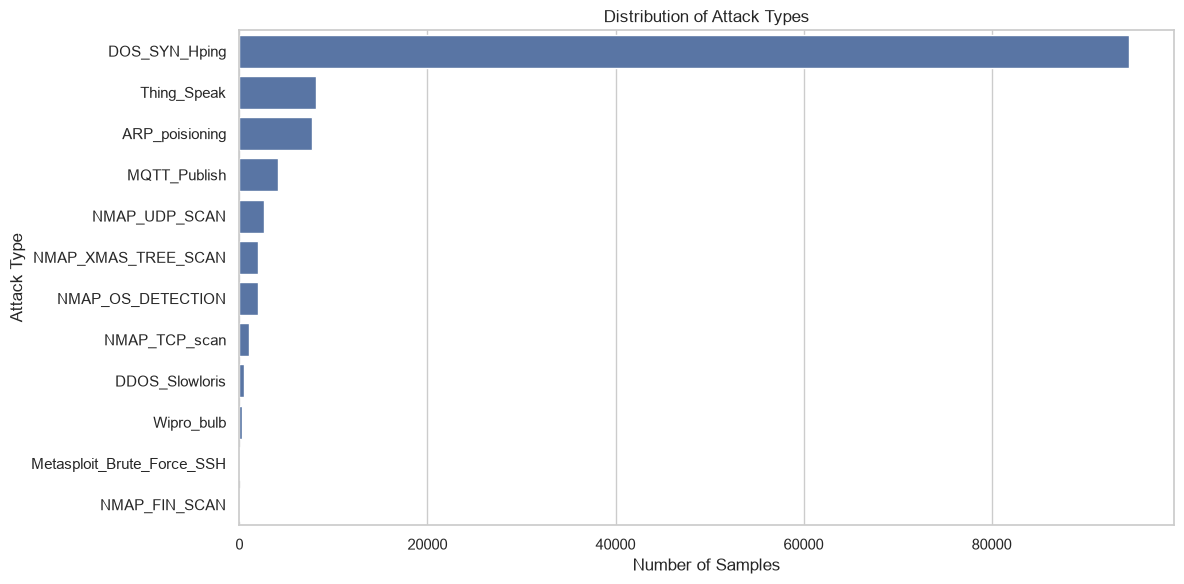

In [10]:
target_counts = df['Attack_type'].value_counts()

print(target_counts)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=target_counts.values,
    y=target_counts.index
)

plt.title("Distribution of Attack Types")
plt.xlabel("Number of Samples")
plt.ylabel("Attack Type")
plt.tight_layout()
plt.show()

### Observation

The target classes are highly imbalanced. `DOS_SYN_Hping` contains the largest number of observations, while classes such as `NMAP_FIN_SCAN` and `Metasploit_Brute_Force_SSH` contain considerably fewer observations.

Therefore, the dataset should be treated as an imbalanced classification dataset during model evaluation. Accuracy alone may not provide a complete picture of classification performance, so metrics such as weighted F1-score and the confusion matrix will also be considered.

In [11]:
target_percentage = df['Attack_type'].value_counts(normalize=True) * 100

target_table = pd.DataFrame({
    'Count': df['Attack_type'].value_counts(),
    'Percentage': target_percentage.round(2)
})

display(target_table)

,Count,Percentage
Attack_type,,
DOS_SYN_Hping,94659,76.89
Thing_Speak,8108,6.59
ARP_poisioning,7750,6.29
MQTT_Publish,4146,3.37
NMAP_UDP_SCAN,2590,2.10
NMAP_XMAS_TREE_SCAN,2010,1.63
NMAP_OS_DETECTION,2000,1.62
NMAP_TCP_scan,1002,0.81
DDOS_Slowloris,534,0.43


## 7. Categorical Feature Distributions

The categorical features are analysed using count plots. These plots show the frequency of different protocol and service categories in the dataset.

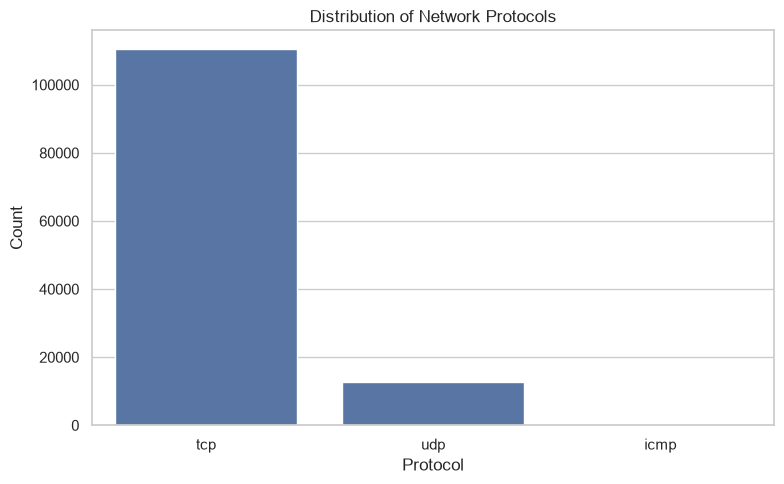

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='proto',
    order=df['proto'].value_counts().index
)

plt.title("Distribution of Network Protocols")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Observation – Protocol Distribution

The dataset is dominated by TCP traffic, followed by UDP traffic. ICMP represents only a small portion of the observations. This indicates that the protocol distribution is highly uneven.

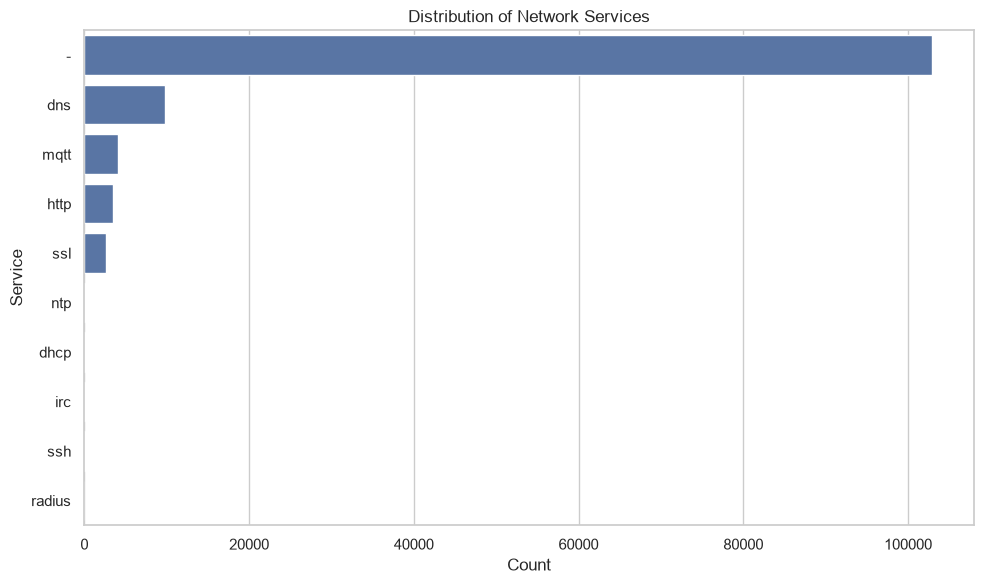

In [13]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y='service',
    order=df['service'].value_counts().index
)

plt.title("Distribution of Network Services")
plt.xlabel("Count")
plt.ylabel("Service")
plt.tight_layout()
plt.show()

### Observation – Service Distribution

The `service` feature contains several network services. The `-` category occurs most frequently, while services such as DNS, MQTT, HTTP and SSL occur less frequently. This shows that network traffic is concentrated in a small number of service categories.

## 8. Distribution of Numerical Features

Histograms are generated for all numerical features to examine their distributions, skewness, concentration and possible extreme values.

Since the dataset contains many numerical features, the plots are generated automatically in batches.

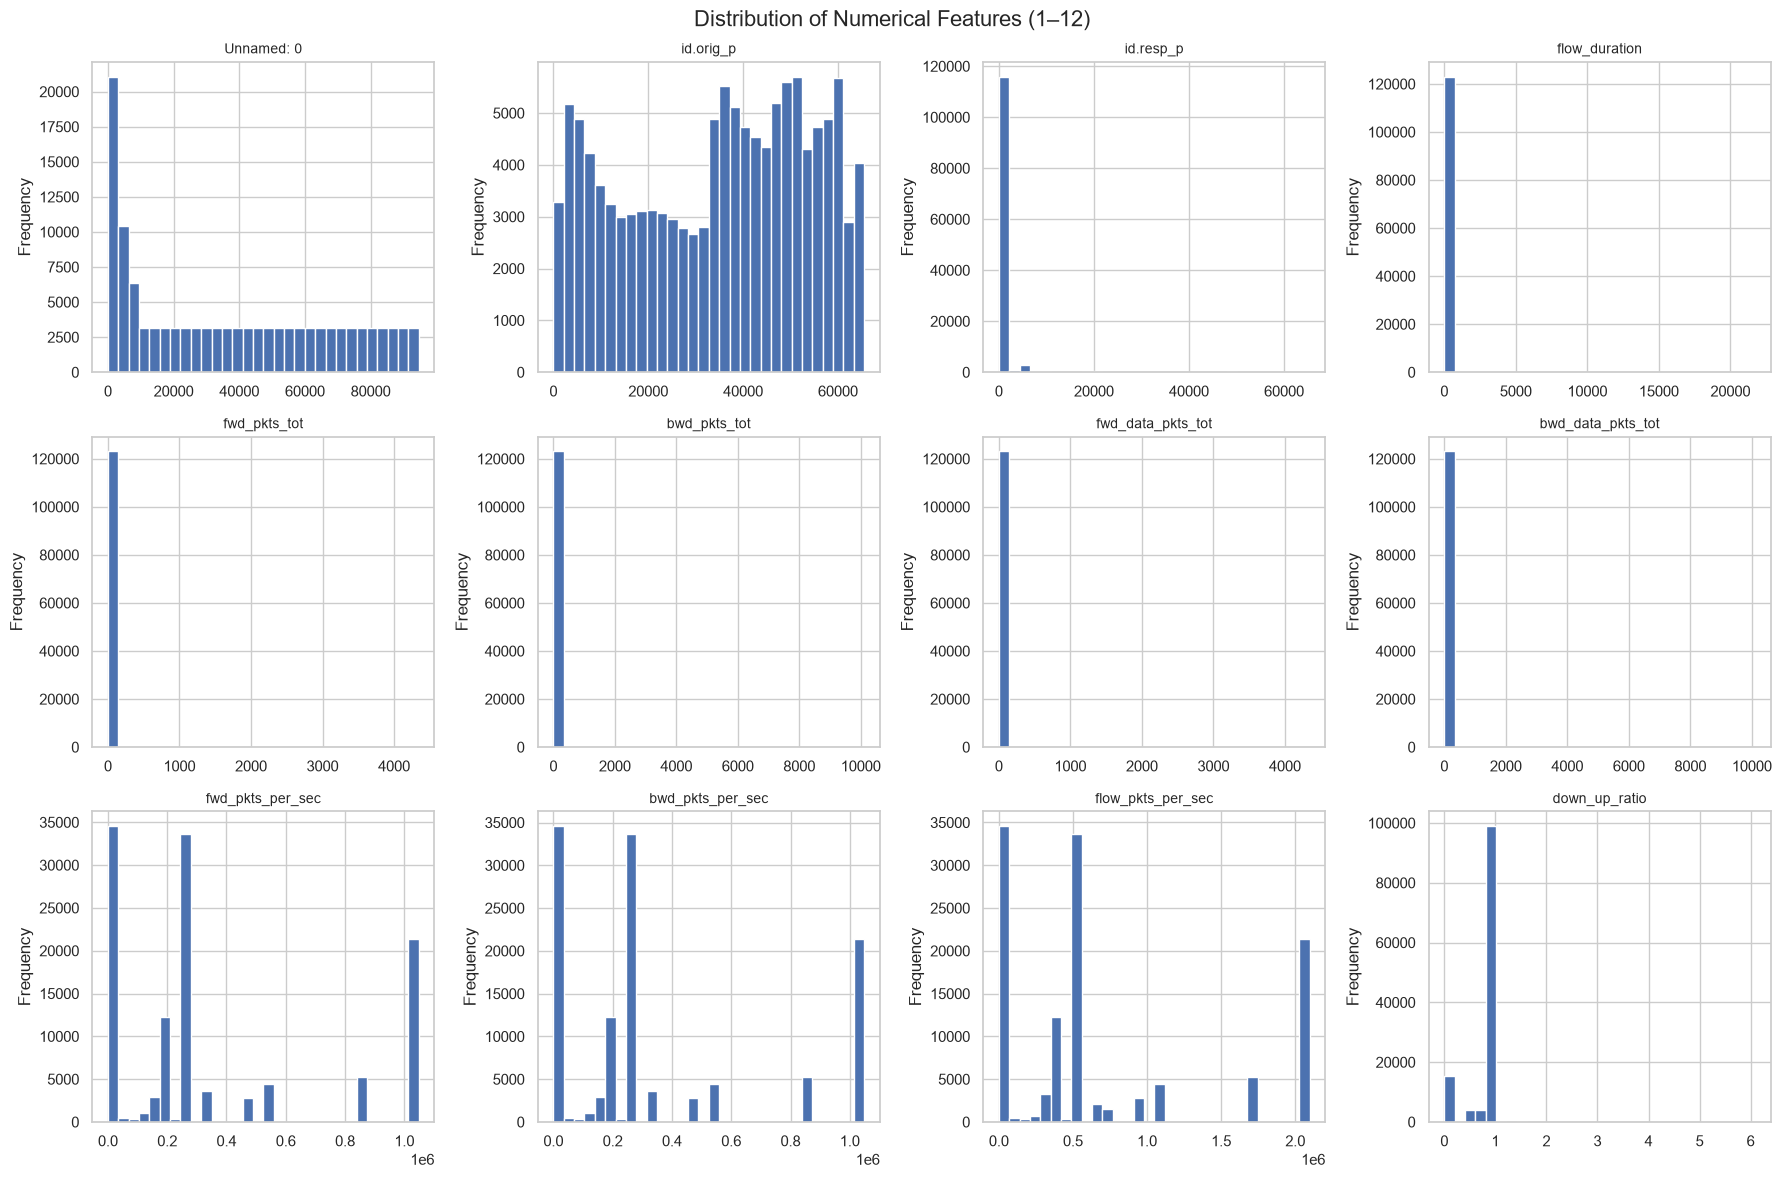

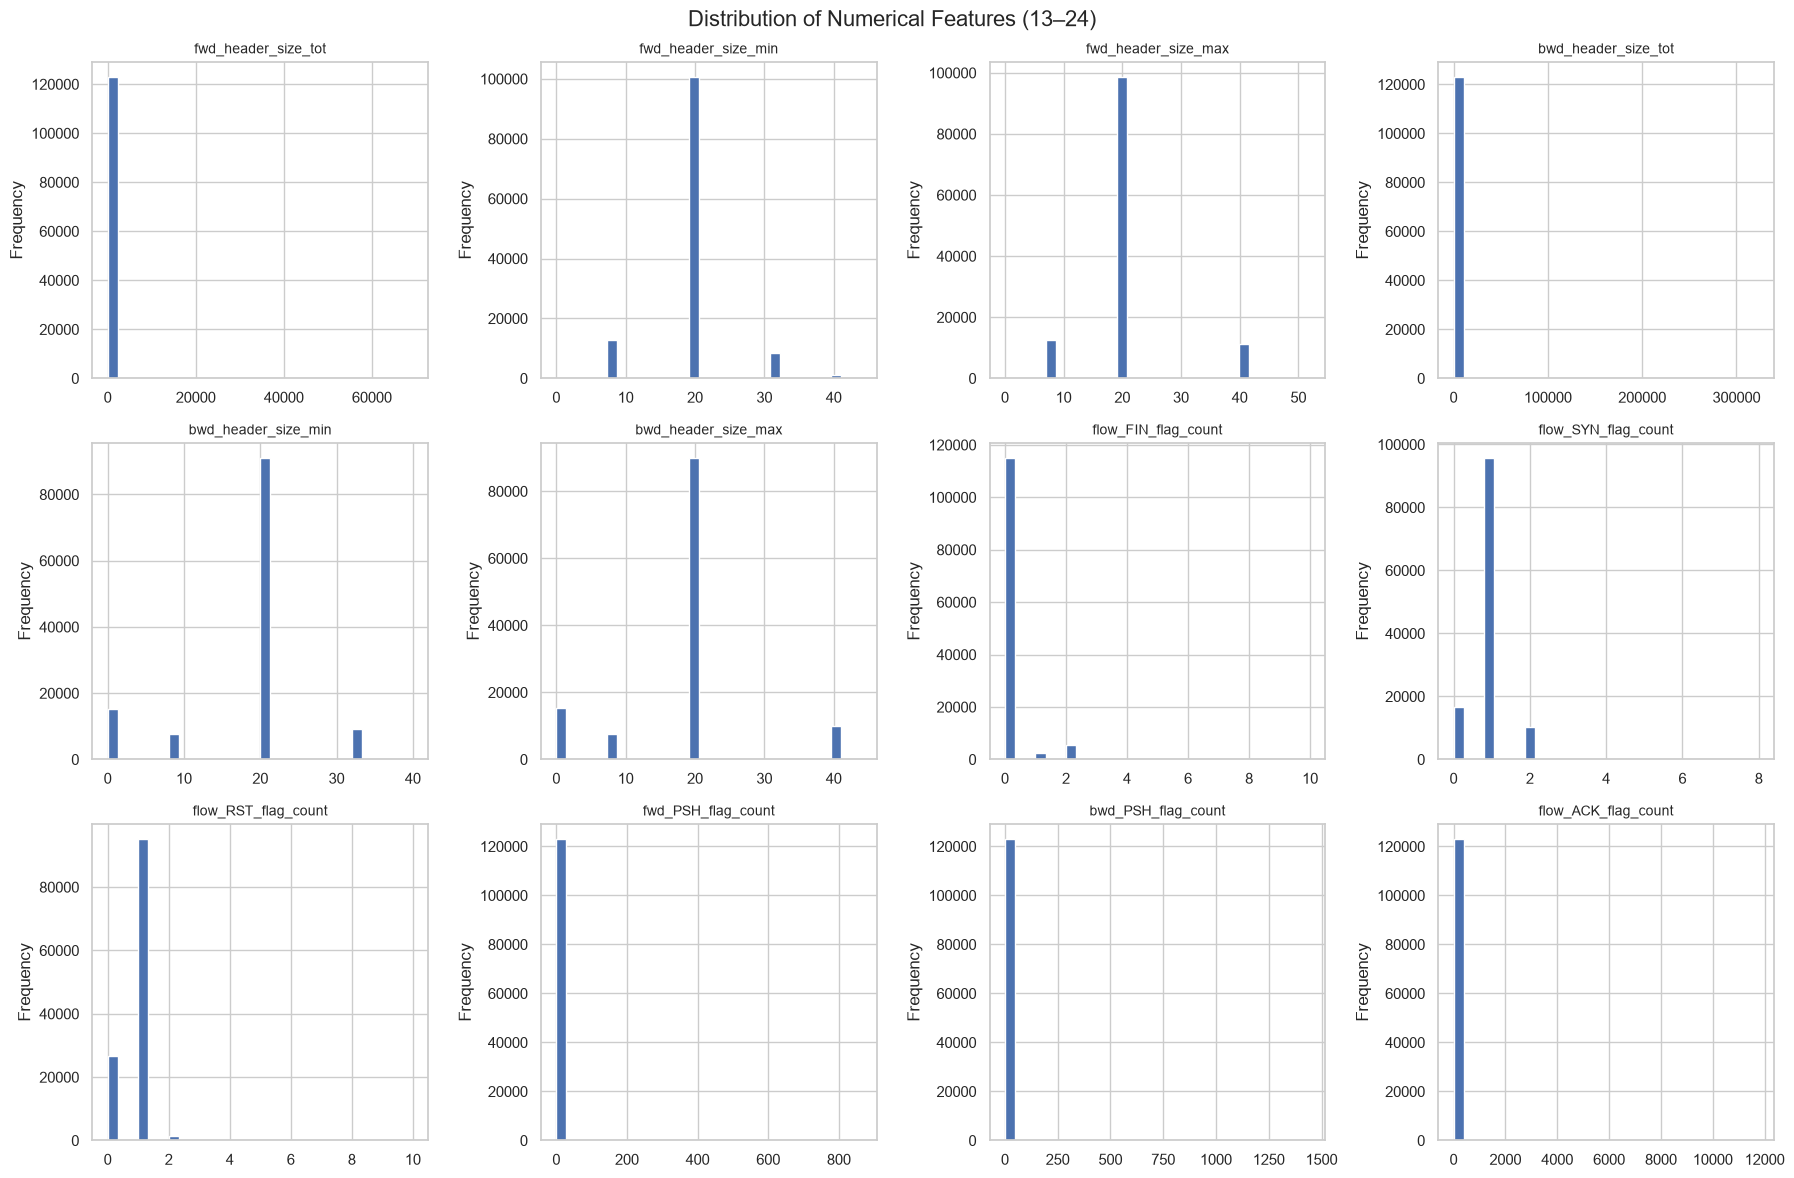

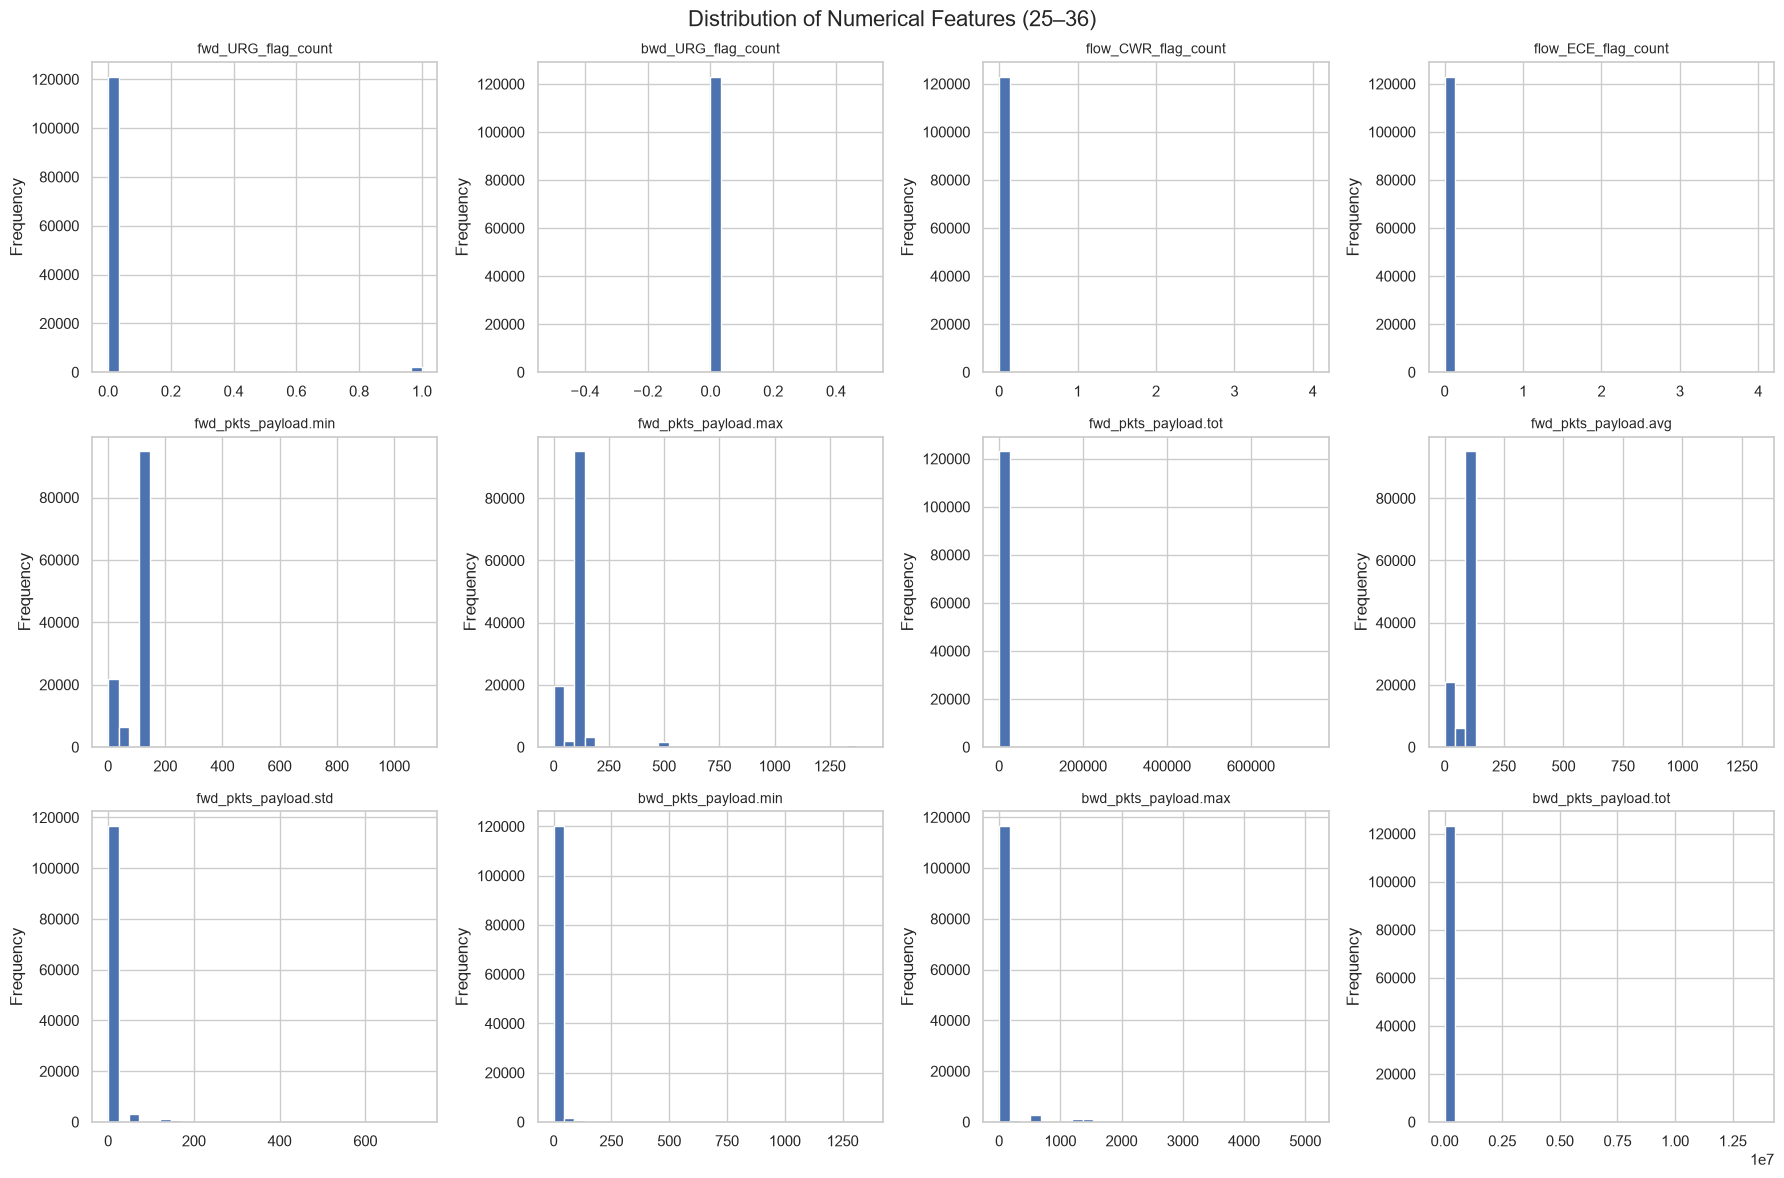

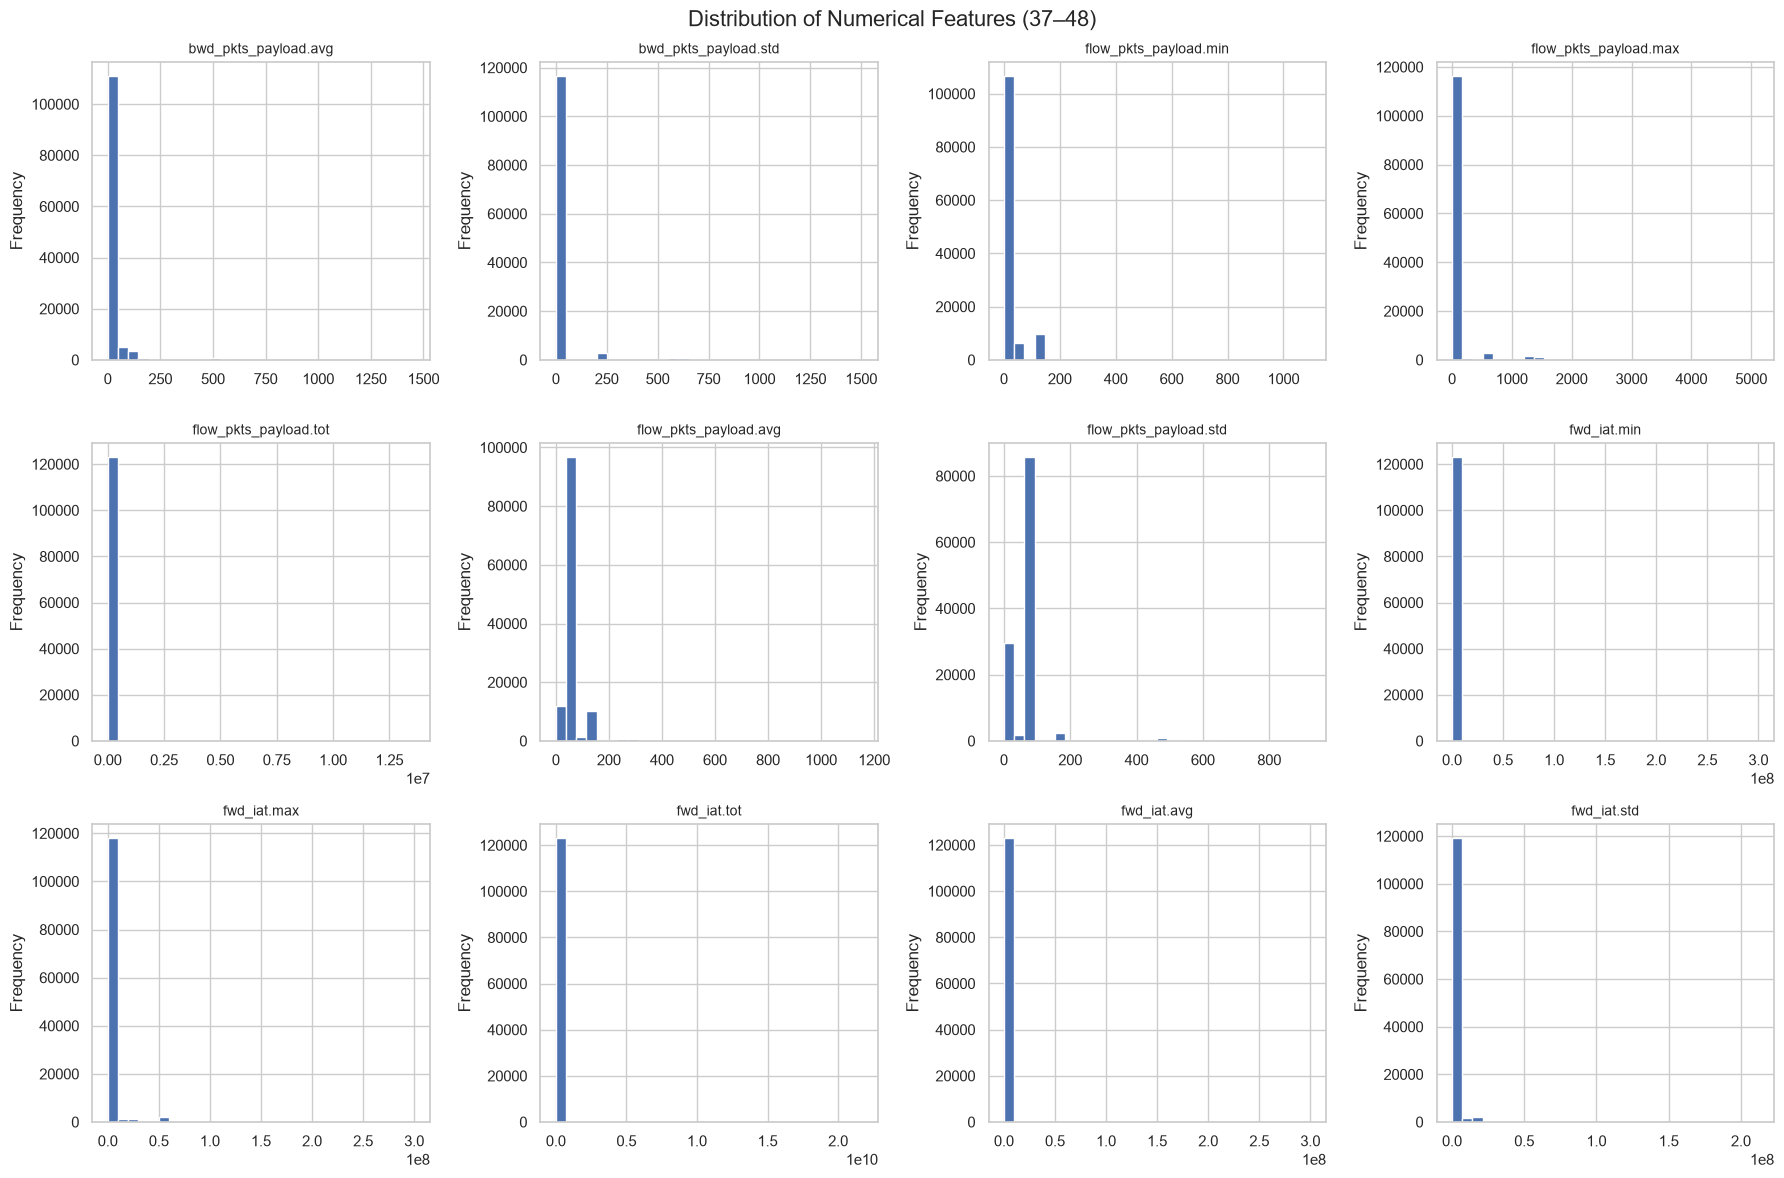

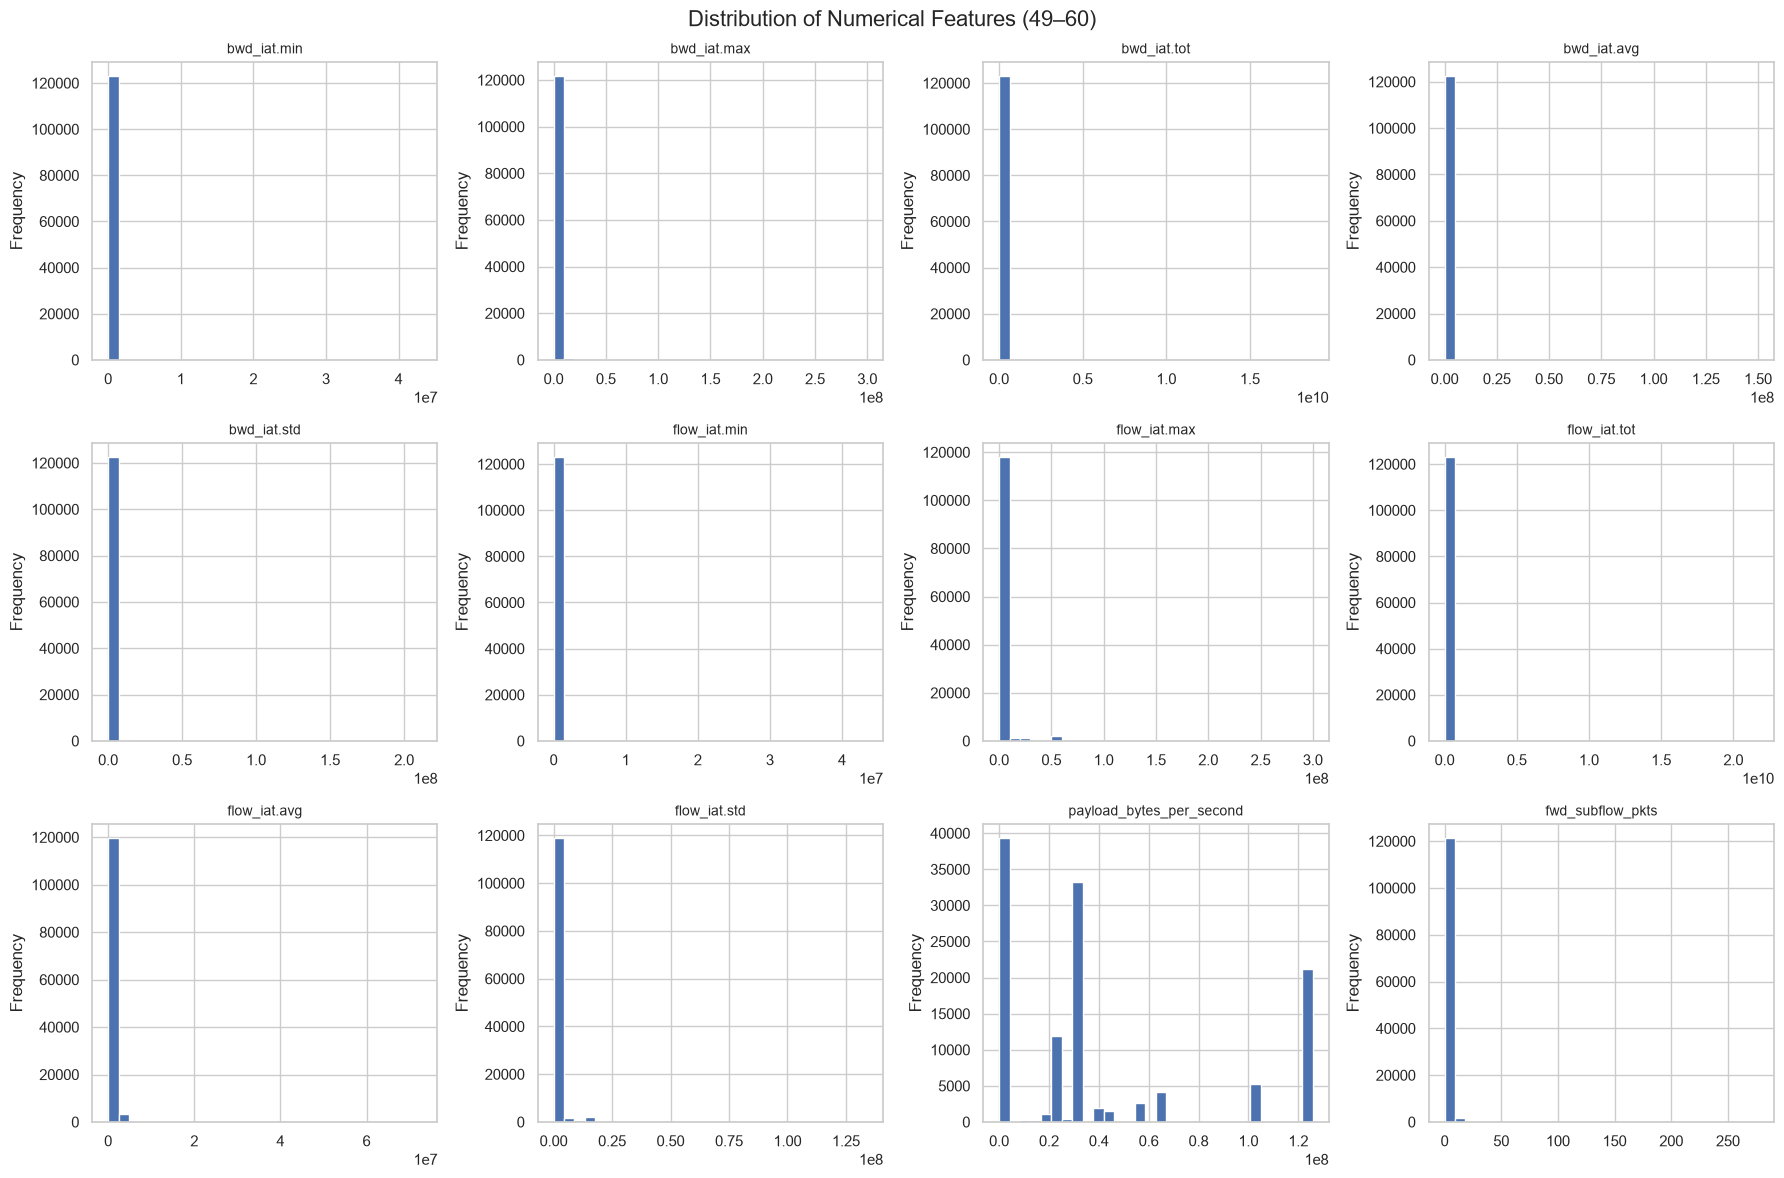

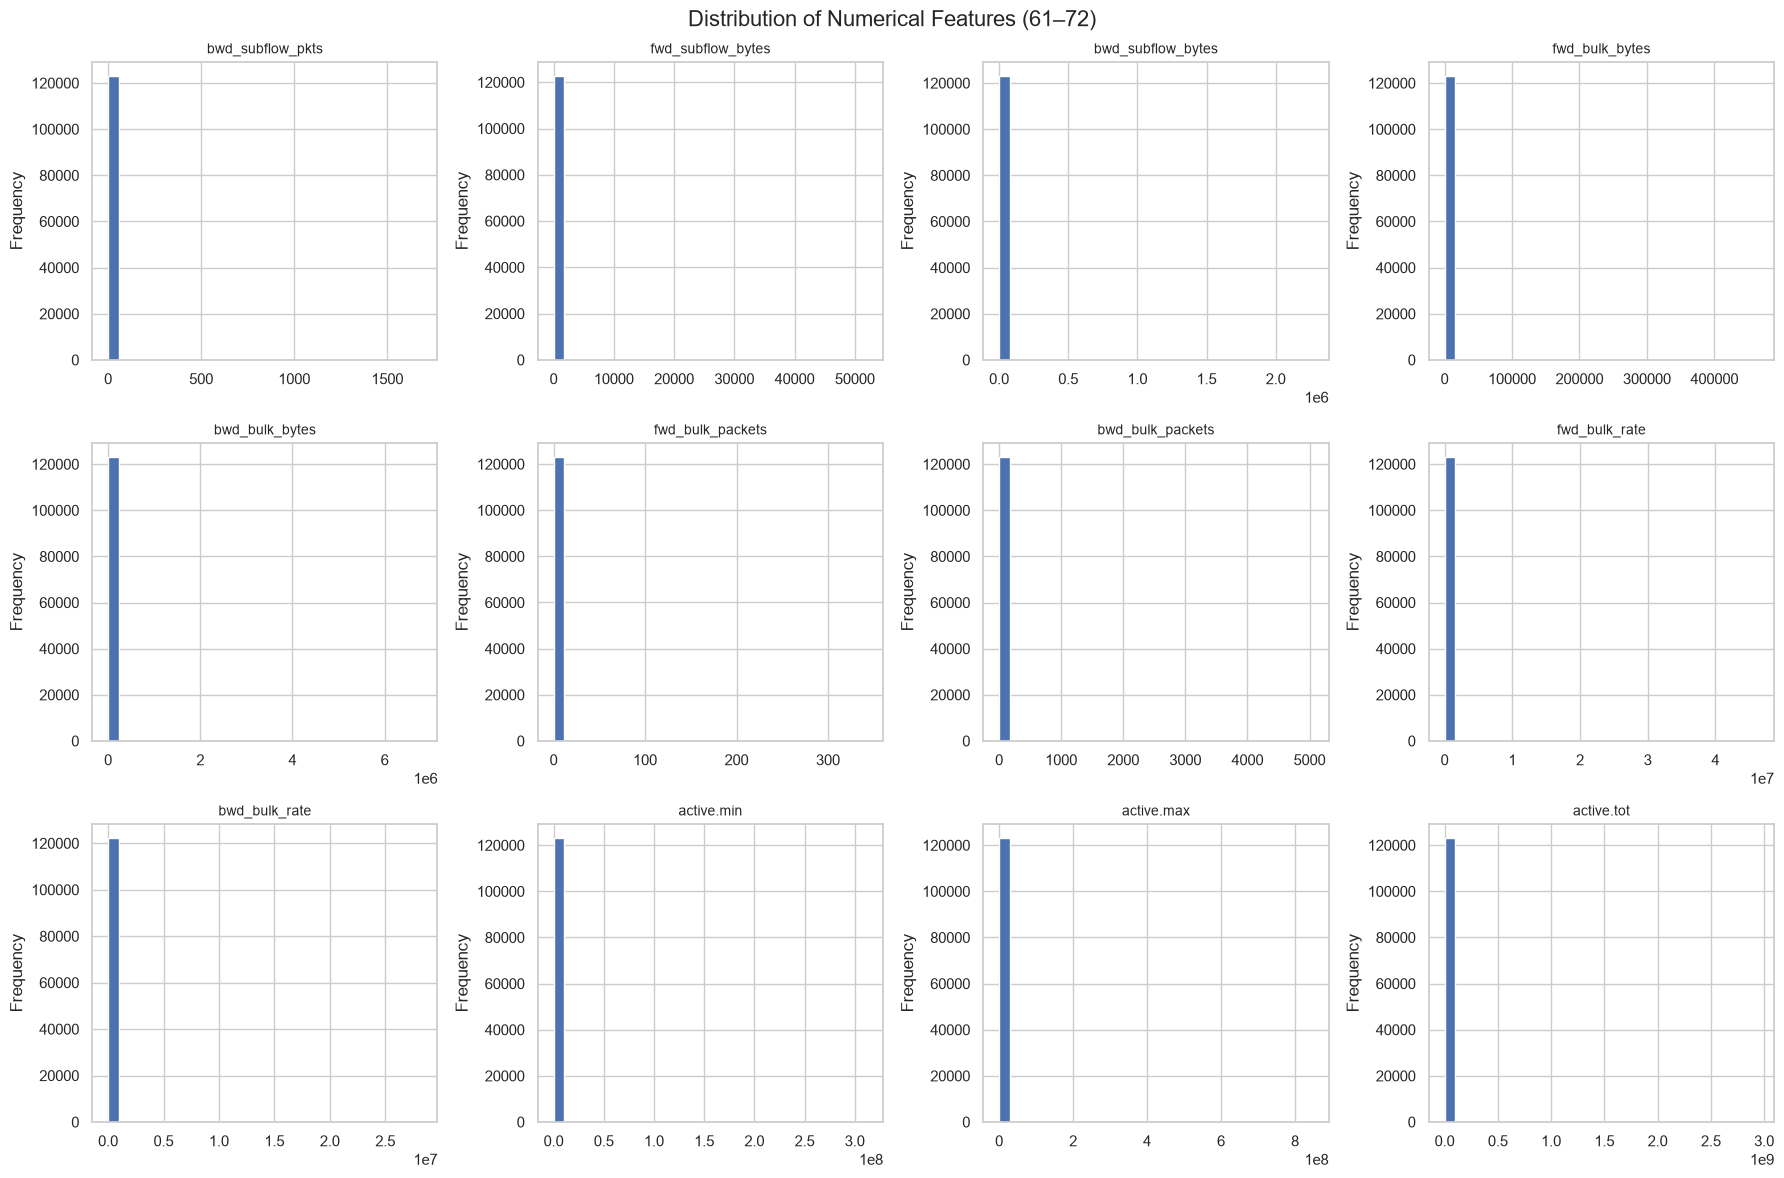

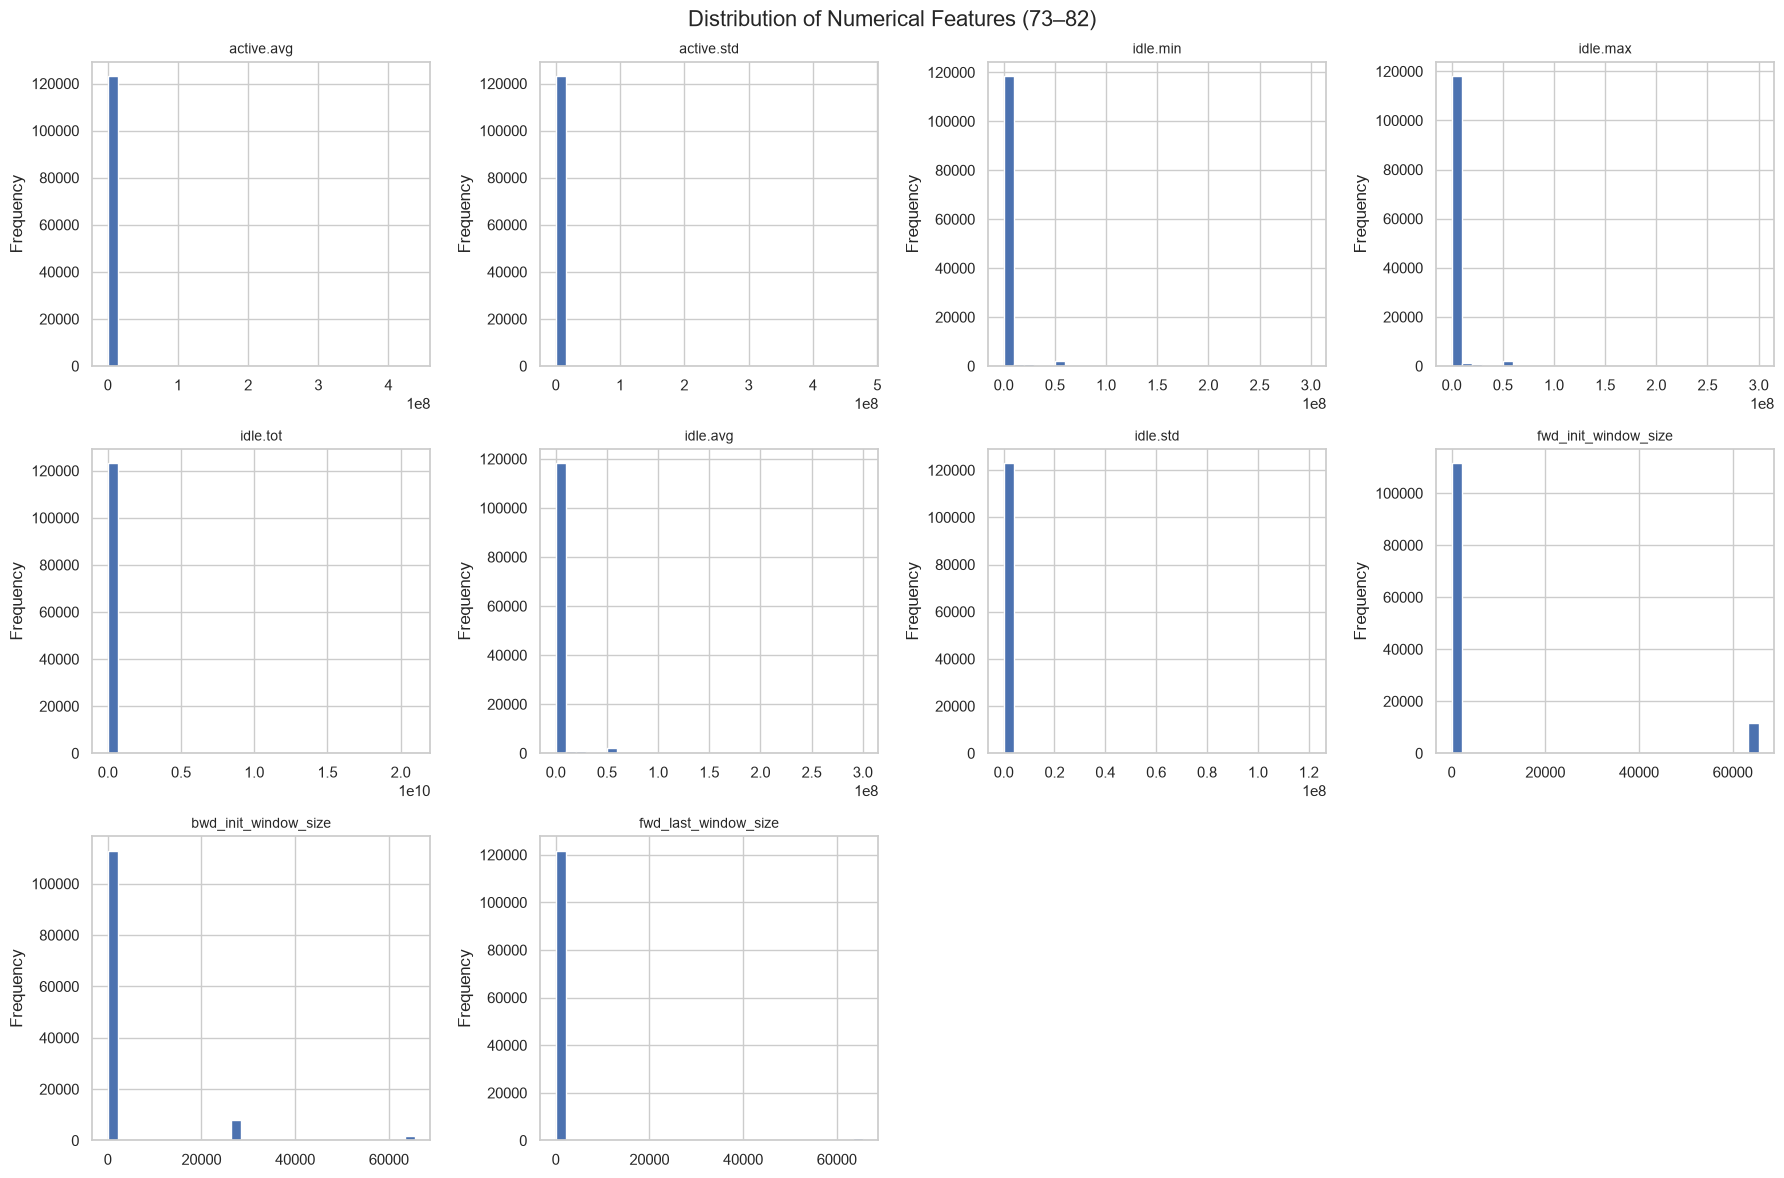

In [14]:
# Plot all numerical features in batches

for start in range(0, len(numeric_features), 12):
    
    batch = numeric_features[start:start + 12]
    
    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, column in enumerate(batch):
        axes[i].hist(df[column].dropna(), bins=30)
        axes[i].set_title(column, fontsize=10)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Frequency")
    
    # Hide unused plots
    for j in range(len(batch), len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(
        f"Distribution of Numerical Features ({start+1}–{start+len(batch)})",
        fontsize=16
    )
    
    plt.tight_layout()
    plt.show()

In [15]:
skewness = df[numeric_features].skew().sort_values(ascending=False)

skewness_table = pd.DataFrame({
    'Skewness': skewness
})

display(skewness_table)

,Skewness
bwd_bulk_bytes,340.497528
bwd_bulk_packets,340.490987
active.std,287.992755
bwd_pkts_payload.tot,280.814630
flow_pkts_payload.tot,271.972274
bwd_header_size_tot,269.075835
bwd_data_pkts_tot,264.030712
bwd_pkts_tot,249.909345
fwd_iat.min,238.881011
active.max,234.461542


### Observation – Numerical Distributions

The numerical features exhibit different distributions and scales. Several network-flow features are strongly skewed, with many observations concentrated near smaller values and a smaller number of observations having very large values. This indicates the presence of potential extreme values and suggests that appropriate preprocessing and scaling may be required before model training.

## 9. Outlier Inspection

Boxplots are used to identify potential extreme observations in numerical network-flow features. Outliers are inspected rather than automatically removed because extreme network traffic values may represent genuine attack behaviour.

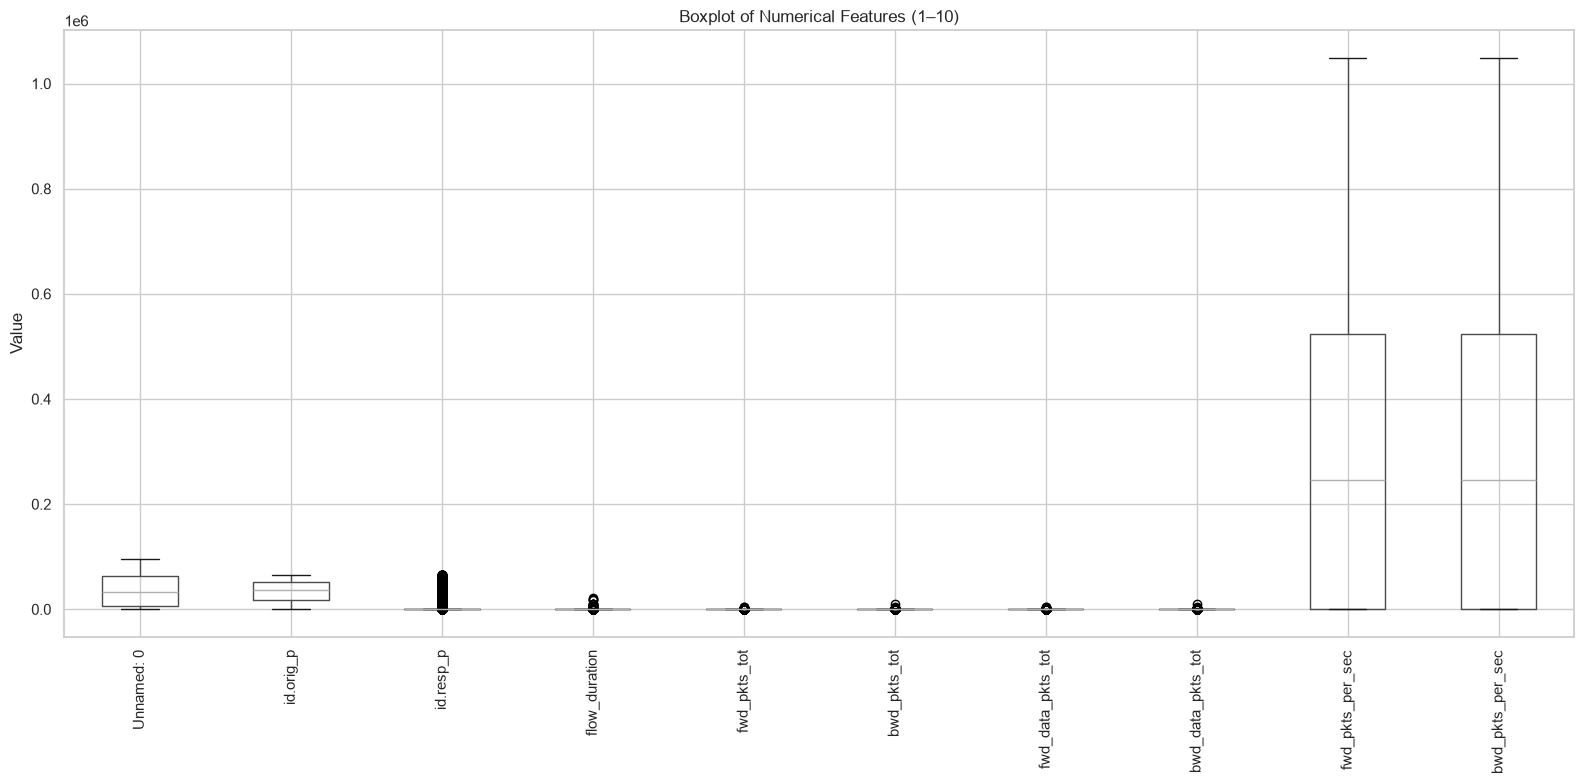

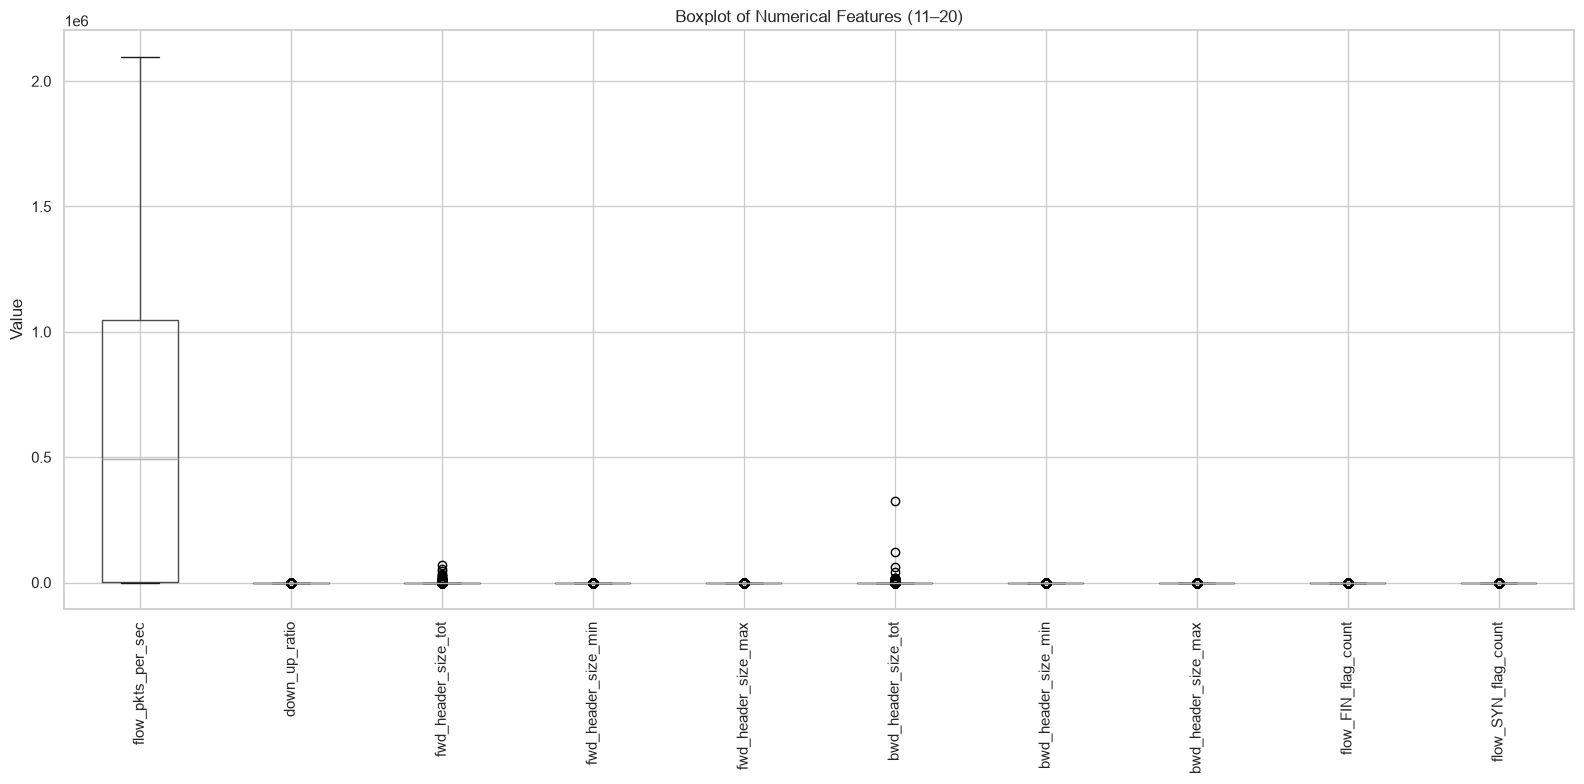

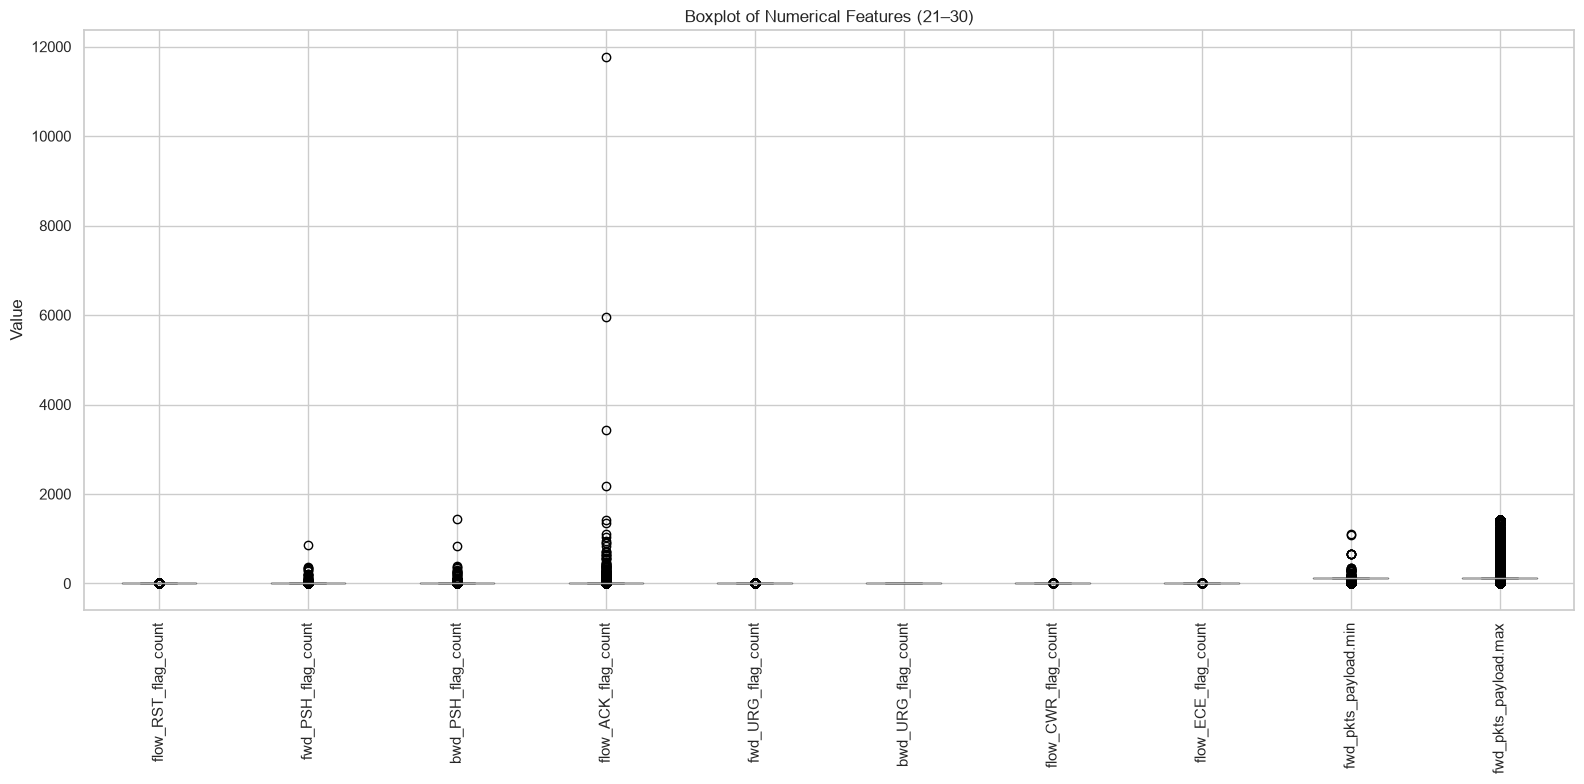

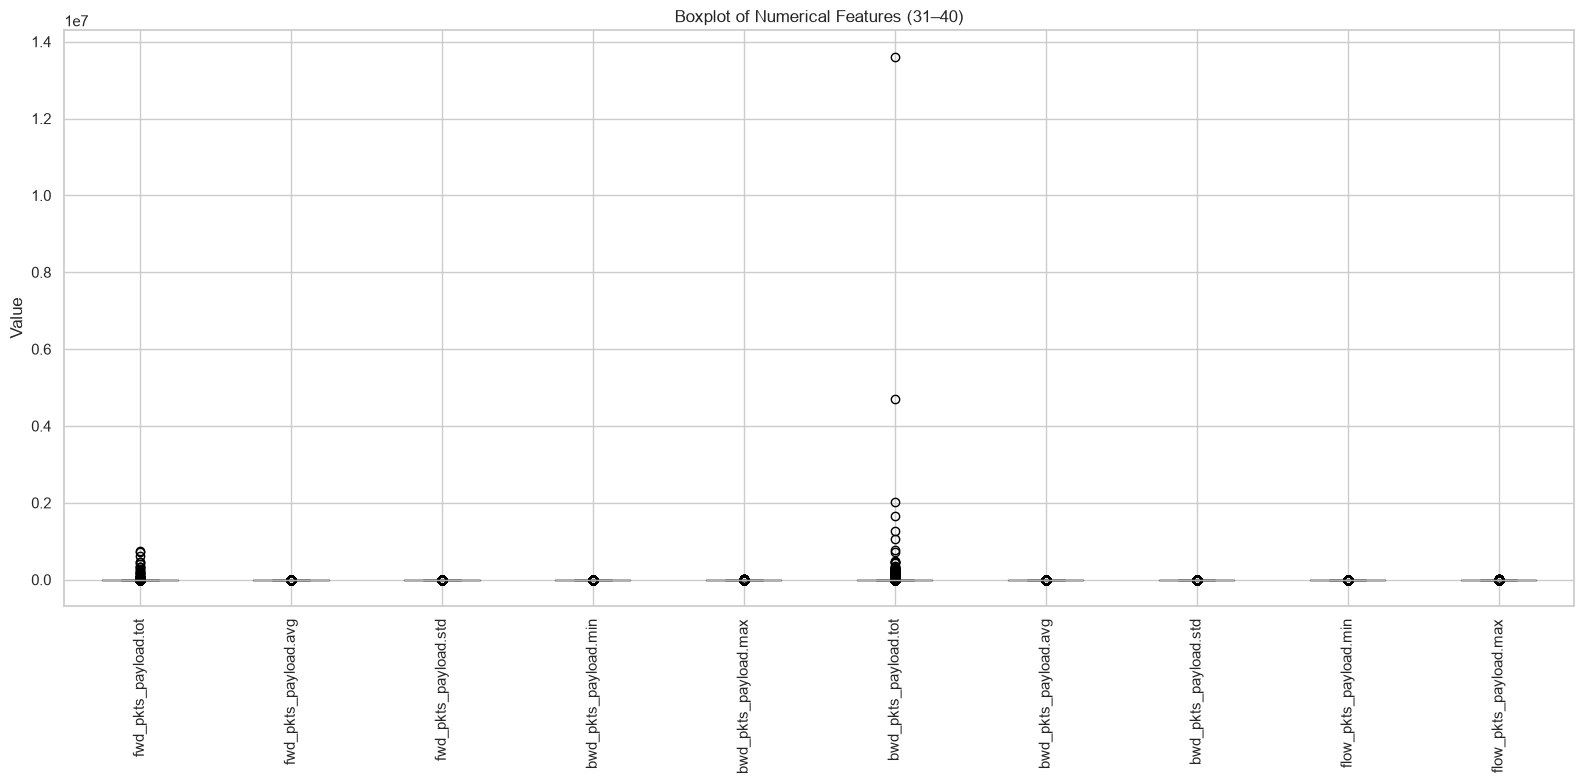

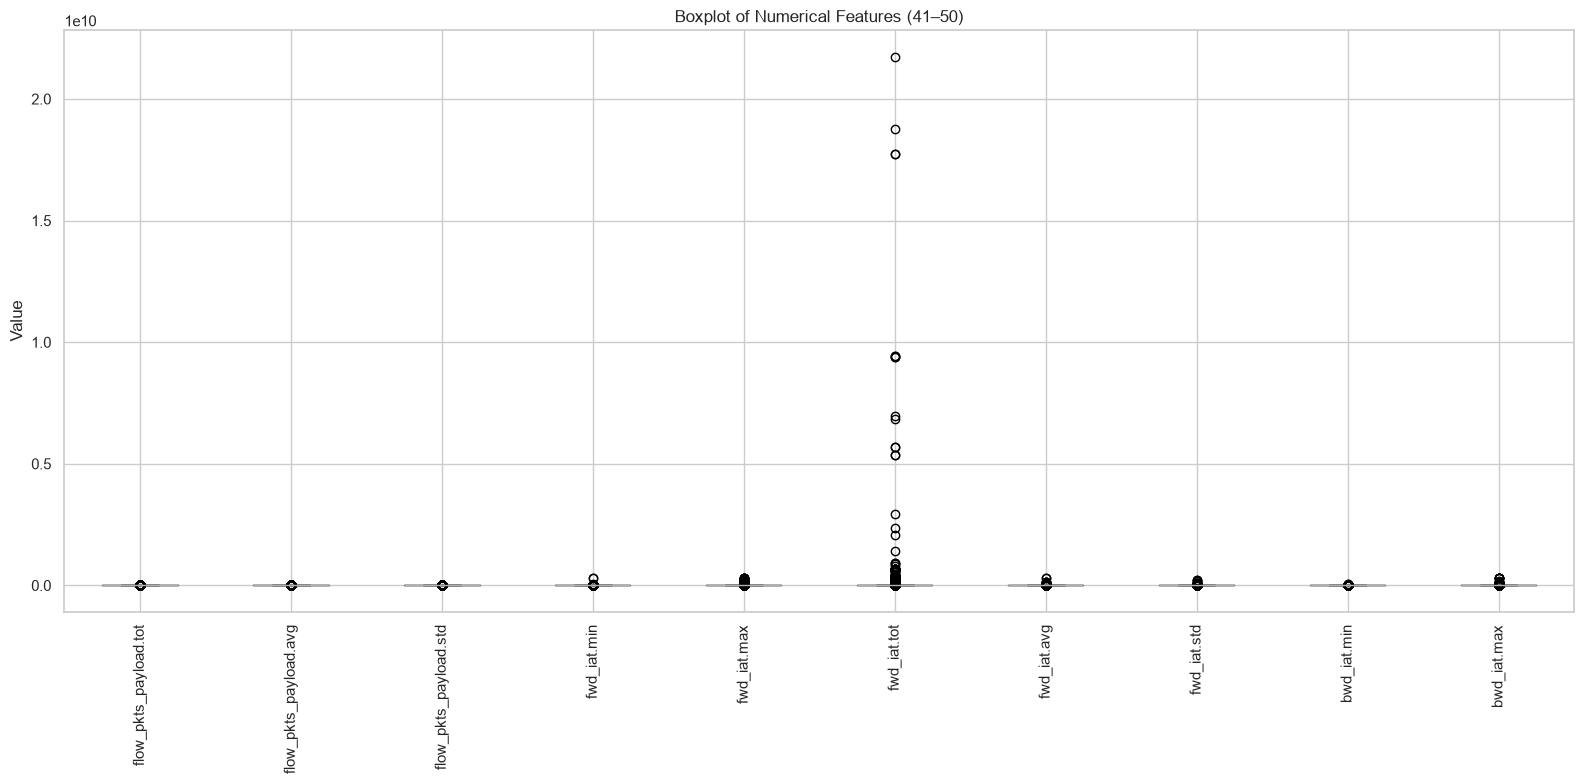

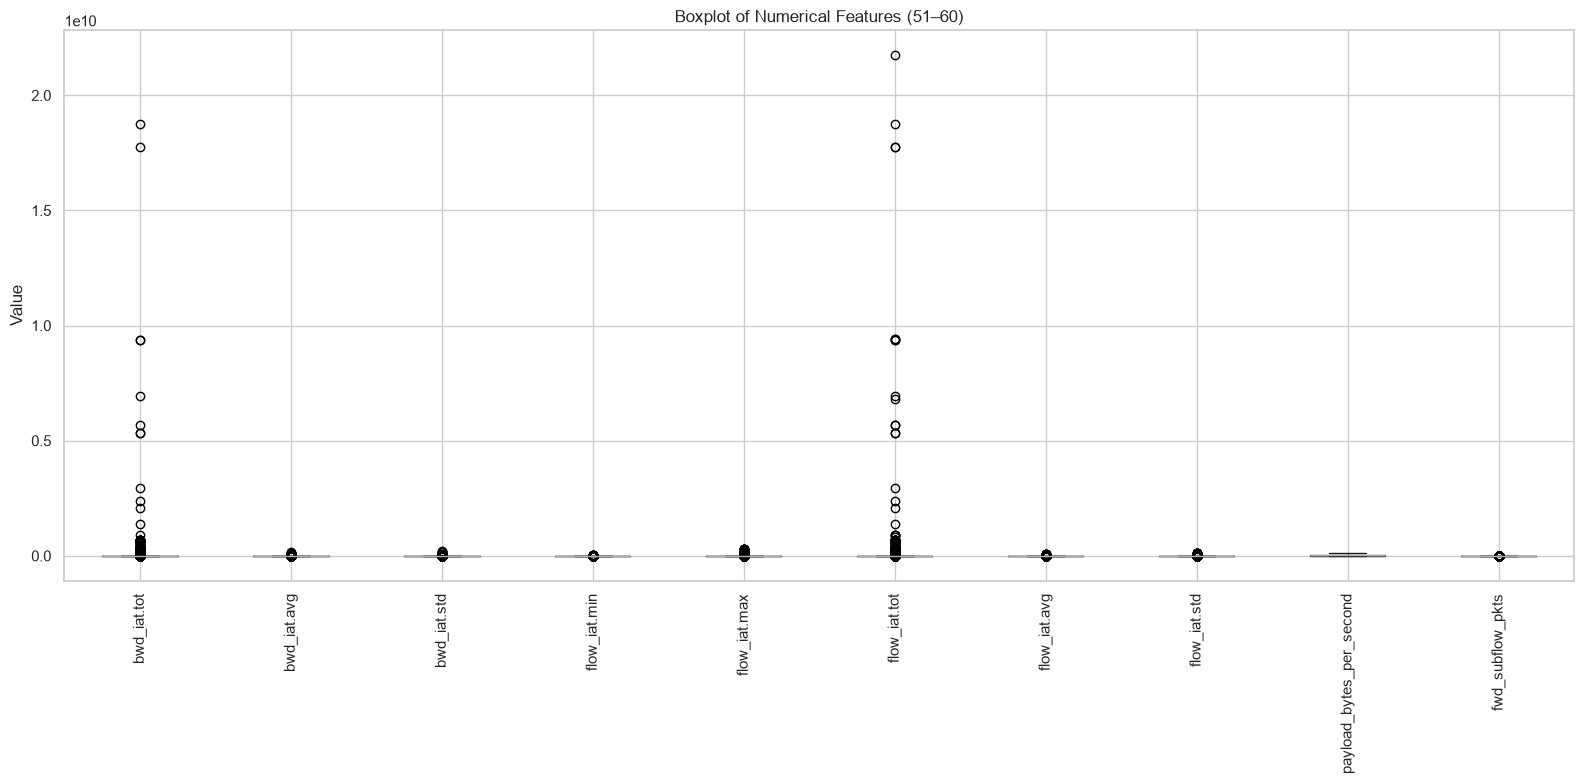

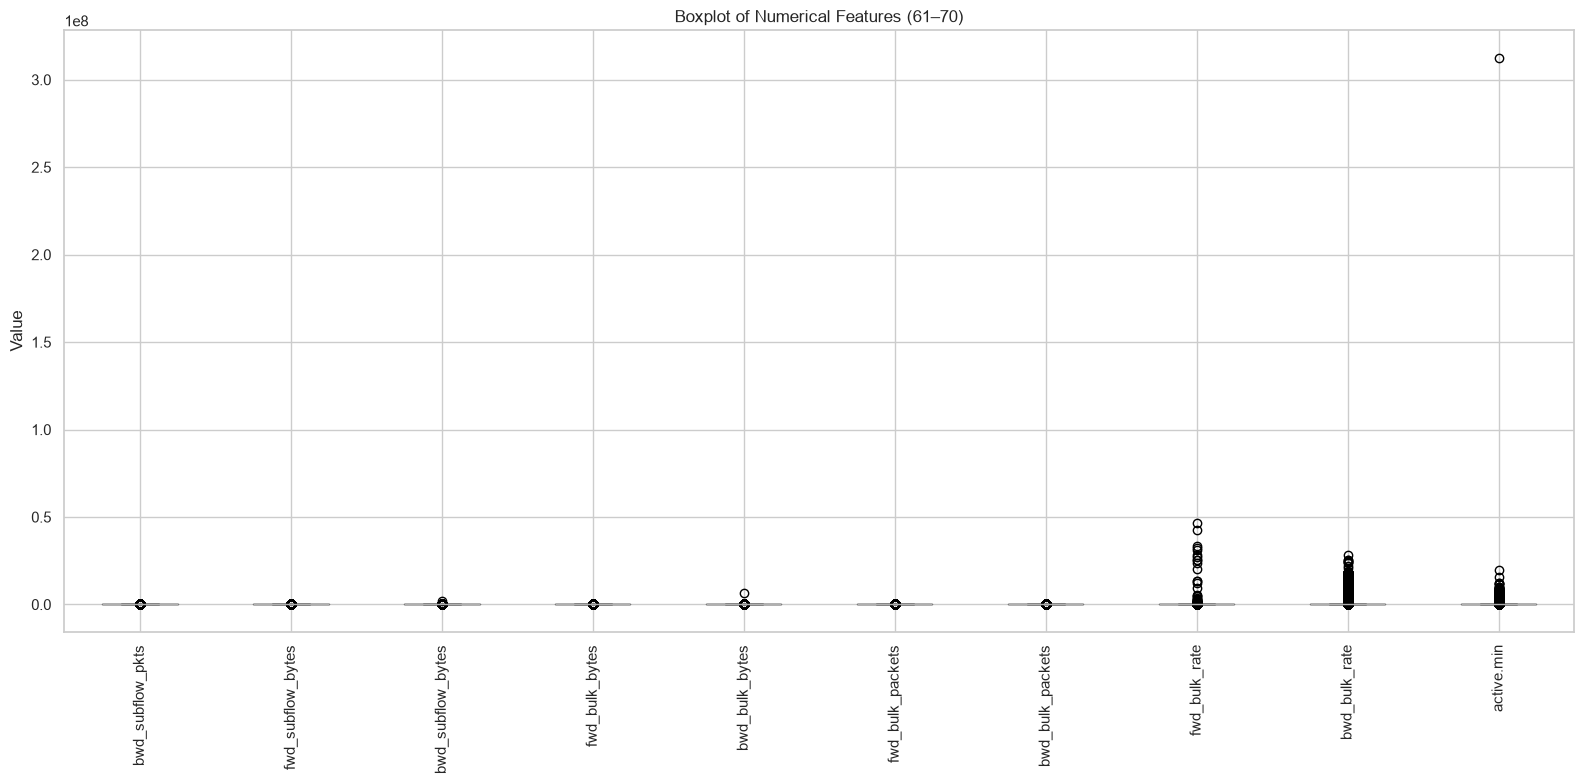

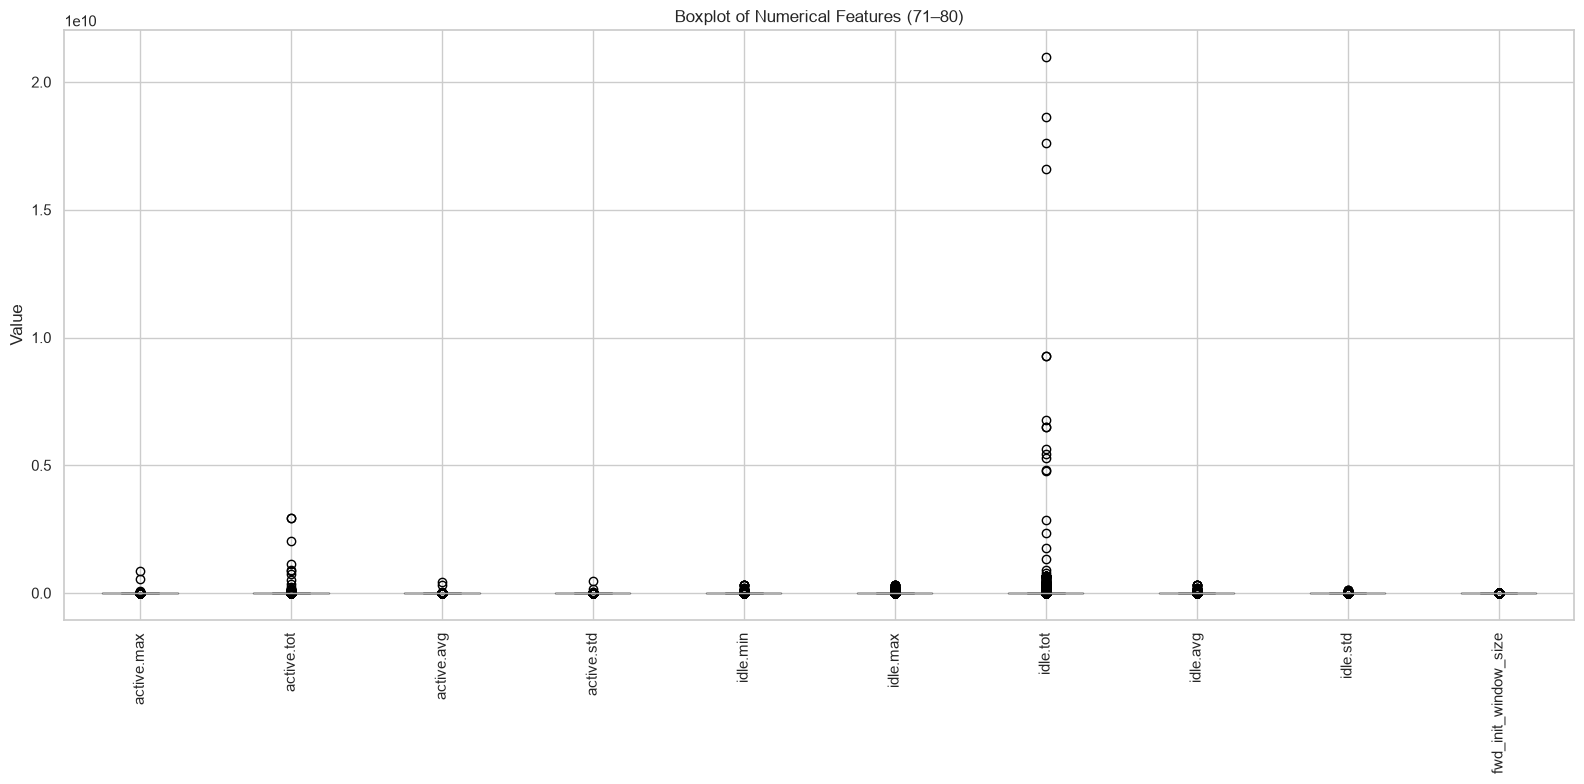

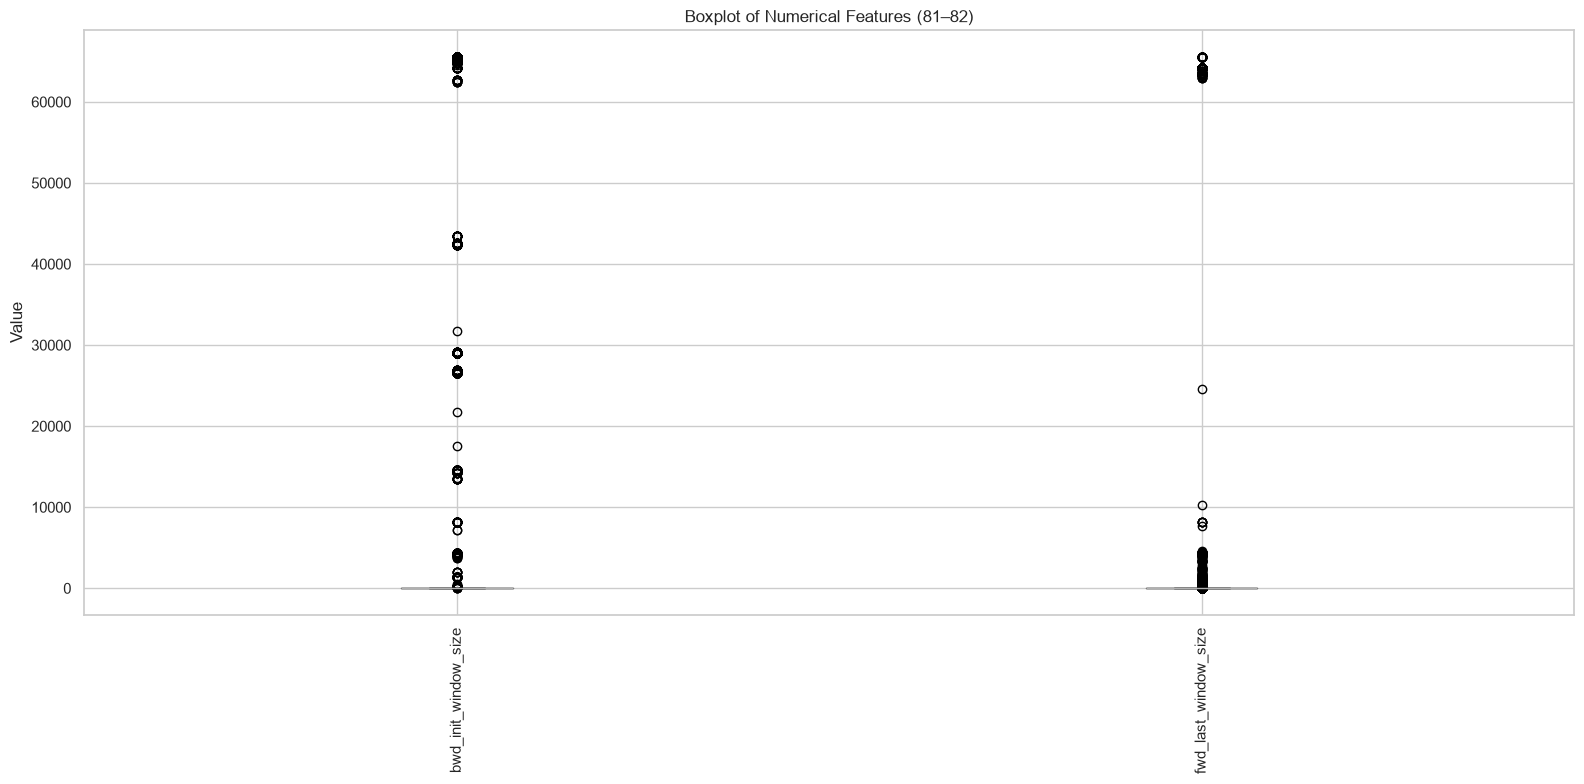

In [16]:
# Boxplots in batches

for start in range(0, len(numeric_features), 10):
    
    batch = numeric_features[start:start + 10]
    
    plt.figure(figsize=(16, 8))
    
    df[batch].boxplot(rot=90)
    
    plt.title(
        f"Boxplot of Numerical Features ({start+1}–{start+len(batch)})"
    )
    
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

In [17]:
outlier_summary = []

for column in numeric_features:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = ((df[column] < lower) | (df[column] > upper)).sum()
    
    outlier_summary.append([column, count])

outlier_table = pd.DataFrame(
    outlier_summary,
    columns=['Feature', 'Potential Outliers']
)

display(
    outlier_table.sort_values(
        'Potential Outliers',
        ascending=False
    ).head(20)
)

,Feature,Potential Outliers
41,flow_pkts_payload.avg,38116
15,bwd_header_size_tot,33148
17,bwd_header_size_max,33137
23,flow_ACK_flag_count,33083
5,bwd_pkts_tot,32364
60,bwd_subflow_pkts,32343
16,bwd_header_size_min,32065
28,fwd_pkts_payload.min,28458
81,fwd_last_window_size,28458
29,fwd_pkts_payload.max,28458


## 10. Correlation Analysis

A correlation matrix is calculated for the numerical features to identify relationships between variables.

A heatmap is used to visualise the strength and direction of these correlations. Highly correlated variables may contain overlapping information and can be considered during feature engineering and model development.

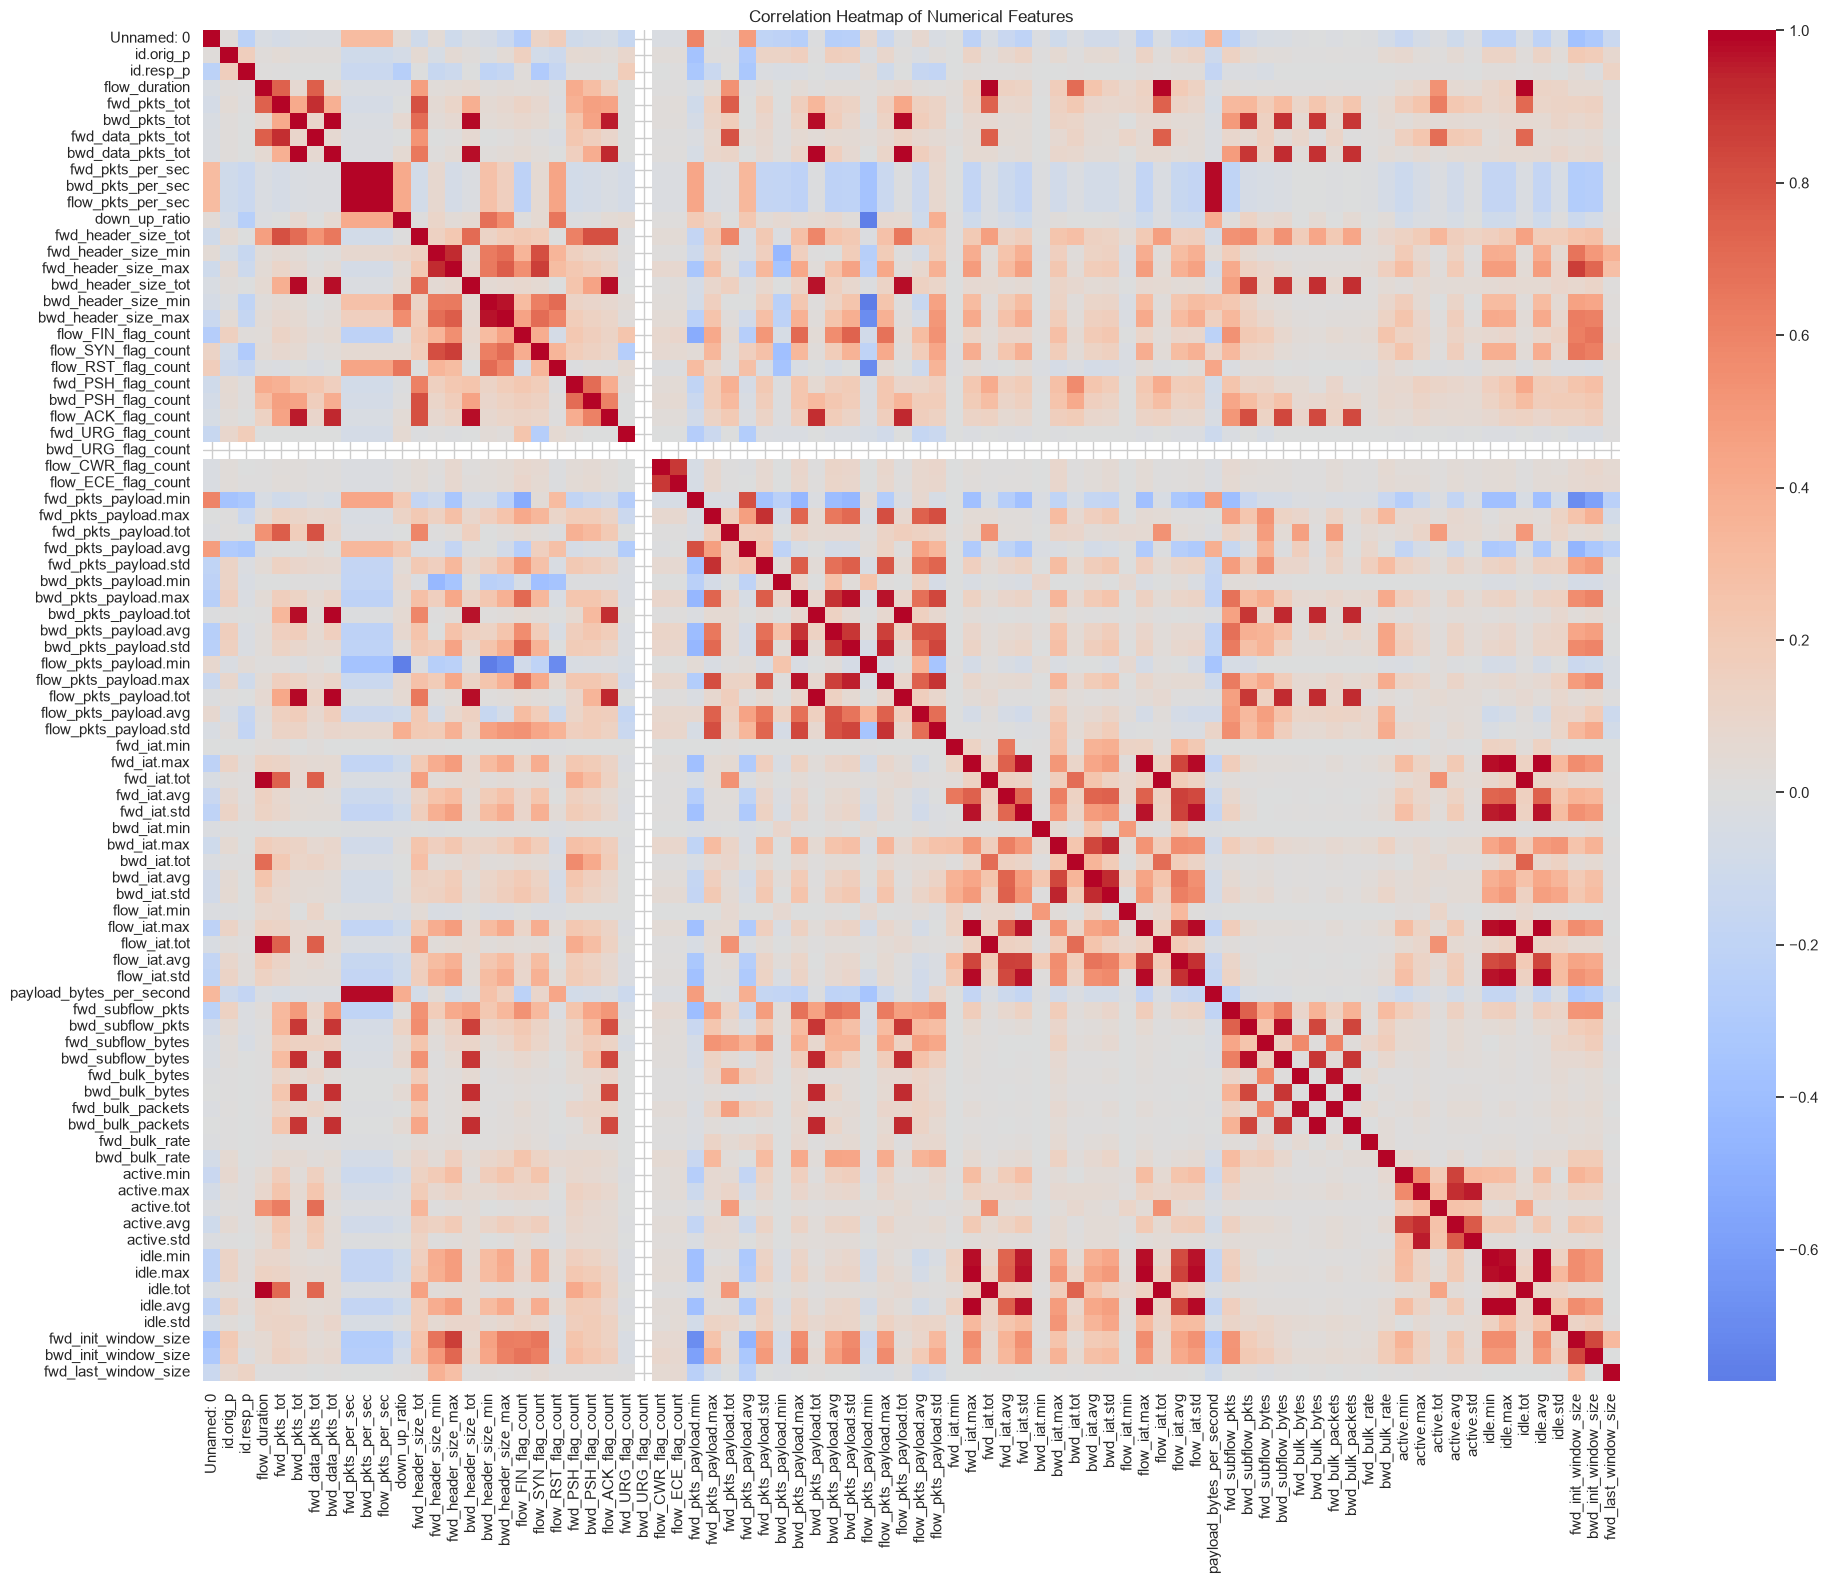

In [18]:
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(20, 16))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0,
    xticklabels=True,
    yticklabels=True
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [19]:
corr_pairs = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

corr_pairs = corr_pairs.stack().sort_values(
    key=abs,
    ascending=False
)

print("Top 20 correlated feature pairs:")
display(corr_pairs.head(20).to_frame(name="Correlation"))

Top 20 correlated feature pairs:


Correlation
flow_duration        flow_iat.tot              1.000000
bwd_pkts_per_sec     flow_pkts_per_sec         0.999997
fwd_pkts_per_sec     flow_pkts_per_sec         0.999997
                     bwd_pkts_per_sec          0.999986
bwd_bulk_bytes       bwd_bulk_packets          0.999802
flow_iat.max         idle.max                  0.999748
fwd_iat.tot          flow_iat.tot              0.999719
flow_duration        fwd_iat.tot               0.999719
fwd_iat.max          flow_iat.max              0.996647
                     idle.max                  0.996389
idle.max             idle.avg                  0.995069
flow_duration        idle.tot                  0.995023
flow_iat.tot         idle.tot                  0.995023
flow_iat.max         idle.avg                  0.994813
fwd_iat.tot          idle.tot                  0.994715
bwd_pkts_payload.tot flow_pkts_payload.tot     0.993704
bwd_pkts_tot         bwd_data_pkts_tot         0.992956
idle.min             idle.avg                  0.992706
bwd_data_pkts_tot    flow_pkts_payload.tot     0.992449
fwd_iat.max          idle.avg                  0.992227

In [20]:
# Calculate mean of numerical features for each attack type

attack_means = df.groupby('Attack_type')[numeric_features].mean()

display(attack_means.T.head(20))

Attack_type,ARP_poisioning,DDOS_Slowloris,DOS_SYN_Hping,MQTT_Publish,Metasploit_Brute_Force_SSH,NMAP_FIN_SCAN,NMAP_OS_DETECTION,NMAP_TCP_scan,NMAP_UDP_SCAN,NMAP_XMAS_TREE_SCAN,Thing_Speak,Wipro_bulb
Unnamed: 0,3874.500000,266.500000,47329.000000,2072.500000,18.000000,13.500000,999.500000,500.500000,1294.500000,1004.500000,4053.500000,126.000000
id.orig_p,46356.856903,52130.758427,30748.834892,47295.251327,37409.756757,51604.035714,48818.000000,47101.371257,56373.898842,47746.946766,45566.648249,46416.146245
id.resp_p,1550.909806,109.574906,21.000000,1881.260492,603.243243,27.392857,8634.848000,8635.353293,21196.941313,8600.152736,512.120005,2879.565217
flow_duration,15.893538,14.699148,0.000003,43.397013,3.006557,0.023614,0.000008,0.000019,0.737766,0.001171,0.934471,586.845727
fwd_pkts_tot,8.296903,6.041199,1.000000,10.171973,12.216216,1.214286,1.000000,1.009980,2.069884,1.003483,5.392452,80.529644
bwd_pkts_tot,8.678065,5.035581,0.897633,8.277858,10.648649,0.321429,1.000000,0.998004,0.011197,0.996517,4.451406,17.126482
fwd_data_pkts_tot,4.436516,2.973783,1.000000,2.992041,5.459459,0.178571,0.000000,0.003992,1.169112,0.002985,2.190923,67.541502
bwd_data_pkts_tot,6.423484,1.123596,0.000000,6.222142,4.378378,0.178571,0.000000,0.000000,0.008108,0.002488,2.674026,11.600791
fwd_pkts_per_sec,1788.029684,3344.628463,444796.206535,0.654702,97.644354,30.424361,211007.472750,416853.084163,1127.896168,174497.435566,41.412894,104.663612
bwd_pkts_per_sec,1680.858865,181.430430,444796.206535,0.539012,97.128578,30.362344,211007.472750,416822.471283,0.824858,174497.435126,38.451637,229.761010


## 11. Feature–Target Relationship: Flow Duration vs Forward Packets

The relationship between flow duration and the number of forward packets is visualised, with observations coloured according to their attack type.

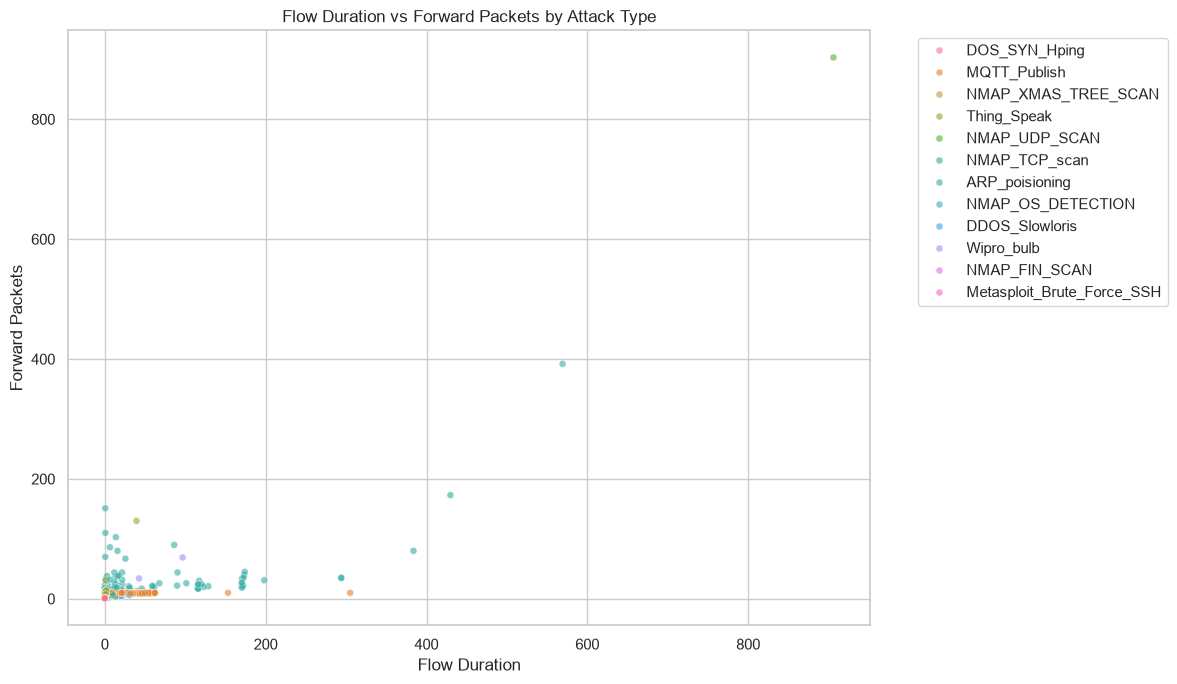

In [21]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df.sample(min(10000, len(df)), random_state=42),
    x='flow_duration',
    y='fwd_pkts_tot',
    hue='Attack_type',
    alpha=0.6,
    s=25
)

plt.title("Flow Duration vs Forward Packets by Attack Type")
plt.xlabel("Flow Duration")
plt.ylabel("Forward Packets")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Observation

The scatter plot shows that different attack types occupy different regions of the flow-duration and forward-packet feature space. Some classes form relatively concentrated groups, while others show wider variation. This indicates that network-flow characteristics can provide useful information for distinguishing different traffic categories.

## 12. Feature–Target Relationship: Forward vs Backward Packets

The relationship between forward and backward packet counts is analysed to determine whether different attack categories exhibit distinct network traffic patterns.

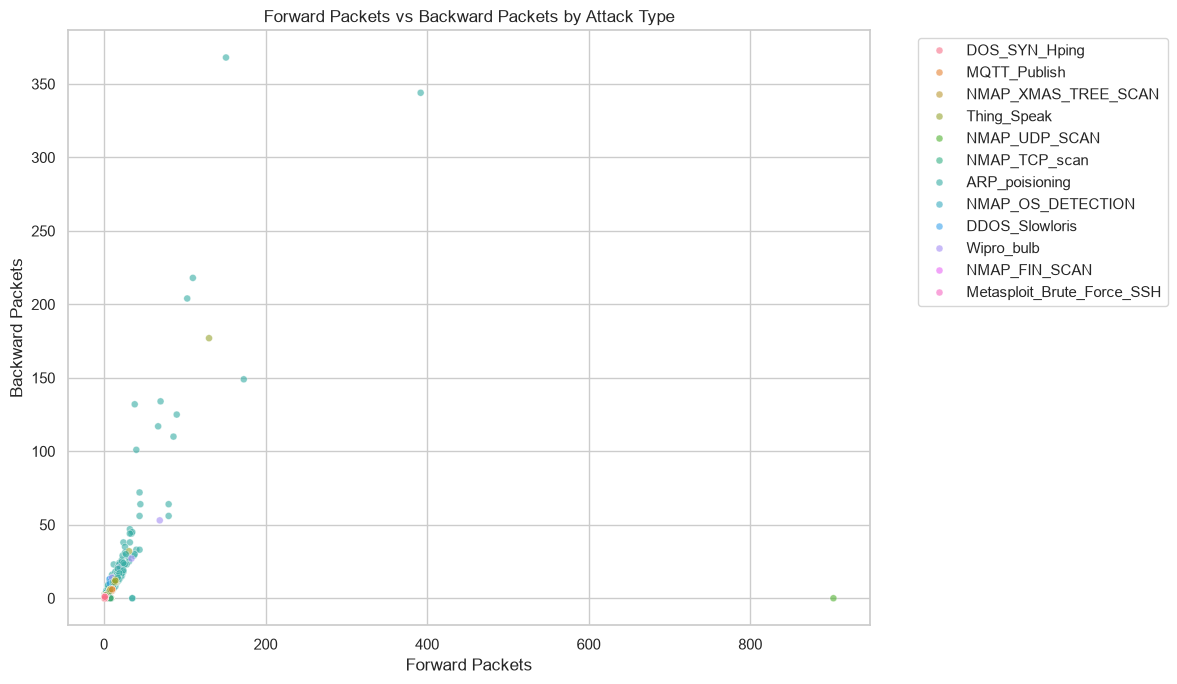

In [22]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df.sample(min(10000, len(df)), random_state=42),
    x='fwd_pkts_tot',
    y='bwd_pkts_tot',
    hue='Attack_type',
    alpha=0.6,
    s=25
)

plt.title("Forward Packets vs Backward Packets by Attack Type")
plt.xlabel("Forward Packets")
plt.ylabel("Backward Packets")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Observation

The relationship between forward and backward packet counts varies across attack categories. Some attack types show concentrated packet-count patterns, whereas other classes show greater variation. This suggests that packet-flow behaviour can contribute to distinguishing different types of network traffic.

## 13. Packet Rate Relationship

Packet rates are compared to investigate whether different attack types demonstrate different network traffic intensities.

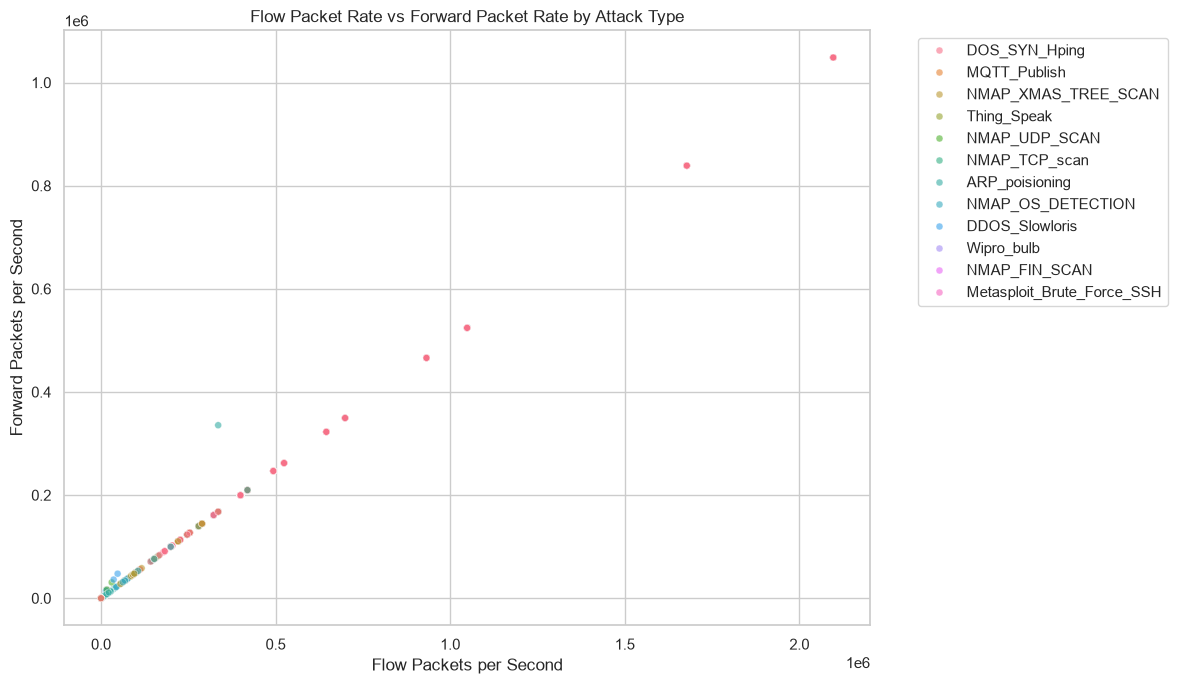

In [23]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df.sample(min(10000, len(df)), random_state=42),
    x='flow_pkts_per_sec',
    y='fwd_pkts_per_sec',
    hue='Attack_type',
    alpha=0.6,
    s=25
)

plt.title("Flow Packet Rate vs Forward Packet Rate by Attack Type")
plt.xlabel("Flow Packets per Second")
plt.ylabel("Forward Packets per Second")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Observation

The packet-rate scatter plot demonstrates variation in network traffic intensity among the attack categories. Certain attack types occupy high-rate regions, while others are concentrated at lower packet rates. This indicates that packet-rate features may provide useful information for classification.

## 14. Numerical Features Across Attack Types

The mean value of numerical features is compared across attack types to identify features whose values vary considerably between classes.

In [24]:
# Calculate mean of numerical features for each attack type

attack_means = df.groupby('Attack_type')[numeric_features].mean()

display(attack_means.head())

,Unnamed: 0,id.orig_p,id.resp_p,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
Attack_type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ARP_poisioning,3874.5,46356.856903,1550.909806,15.893538,8.296903,8.678065,4.436516,6.423484,1788.029684,1680.858865,3468.888548,0.657274,209.304774,13.283613,15.929290,212.015484,9.946323,12.657032,0.431742,0.488516,0.170839,1.953806,2.470194,12.037806,0.0,0.0,0.0,0.0,34.826839,247.159742,1356.803742,73.907196,69.685618,35.837806,375.644645,4978.579484,145.022387,133.462096,36.203871,410.964258,6335.383226,118.030338,126.667278,95814.858990,4.247964e+06,1.558409e+07,7.443455e+05,1.347414e+06,32881.689133,4.175917e+06,1.541380e+07,7.664256e+05,1.408428e+06,24462.984916,4.293432e+06,1.590207e+07,3.940932e+05,1.056489e+06,2.229550e+05,3.661263,3.600210,419.158647,1956.898375,295.224094,1184.969423,0.318539,0.989119,60197.282733,400030.604702,2.470434e+05,5.465839e+05,7.909725e+05,3.366451e+05,1.441287e+05,3.403344e+06,4.164774e+06,1.511110e+07,3.872488e+06,3.657300e+05,15677.245677,10966.410710,1291.419484
DDOS_Slowloris,266.5,52130.758427,109.574906,14.699148,6.041199,5.035581,2.973783,1.123596,3344.628463,181.430430,3526.058894,0.829714,200.749064,29.775281,39.812734,164.209738,22.411985,32.209738,1.544944,2.014981,0.455056,2.953184,1.129213,9.565543,0.0,0.0,0.0,0.0,1.661049,158.998127,205.934457,36.684751,64.917379,0.000000,135.393258,541.573034,47.450550,65.983980,1.661049,247.200375,747.507491,51.188802,93.888251,15769.891525,9.203524e+06,1.469914e+07,2.660823e+06,4.080365e+06,3379.566393,8.488116e+06,1.454247e+07,2.523958e+06,3.830605e+06,15666.843800,8.575873e+06,1.469915e+07,1.171830e+06,2.745964e+06,9.363590e+04,3.495100,1.906492,123.575718,112.541885,1.393258,0.000000,0.009363,0.000000,0.843019,0.000000,6.942071e+04,1.983593e+06,1.984871e+06,7.261016e+05,1.118949e+06,6.086413e+06,8.546138e+06,1.271428e+07,7.316275e+06,1.739288e+06,63853.760300,52469.662921,1125.749064
DOS_SYN_Hping,47329.0,30748.834892,21.000000,0.000003,1.000000,0.897633,1.000000,0.000000,444796.206535,444796.206535,889592.413069,0.897633,20.000000,20.000000,20.000000,17.952651,17.952651,17.952651,0.000000,1.000000,0.897633,0.000000,0.000000,0.897633,0.0,0.0,0.0,0.0,120.000000,120.000000,120.000000,120.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.284093,120.000000,120.000000,66.142047,76.166648,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.727020,2.727020e+00,2.727020e+00,2.727020e+00,0.000000e+00,5.337554e+07,1.000000,0.897633,120.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.727020e+00,2.727020e+00,2.727020e+00,2.7270

In [25]:
# Standard deviation of class means
feature_variation = attack_means.std().sort_values(ascending=False)

print("Features showing high variation across attack types:")

display(
    feature_variation.head(20).to_frame(
        name='Variation Across Attack Types'
    )
)

Features showing high variation across attack types:


,Variation Across Attack Types
flow_iat.tot,1.678600e+08
fwd_iat.tot,1.678398e+08
idle.tot,1.534514e+08
bwd_iat.tot,8.569259e+07
payload_bytes_per_second,1.539803e+07
active.tot,1.442965e+07
fwd_iat.max,1.160798e+07
idle.max,1.159140e+07
flow_iat.max,1.158551e+07
idle.avg,1.148900e+07


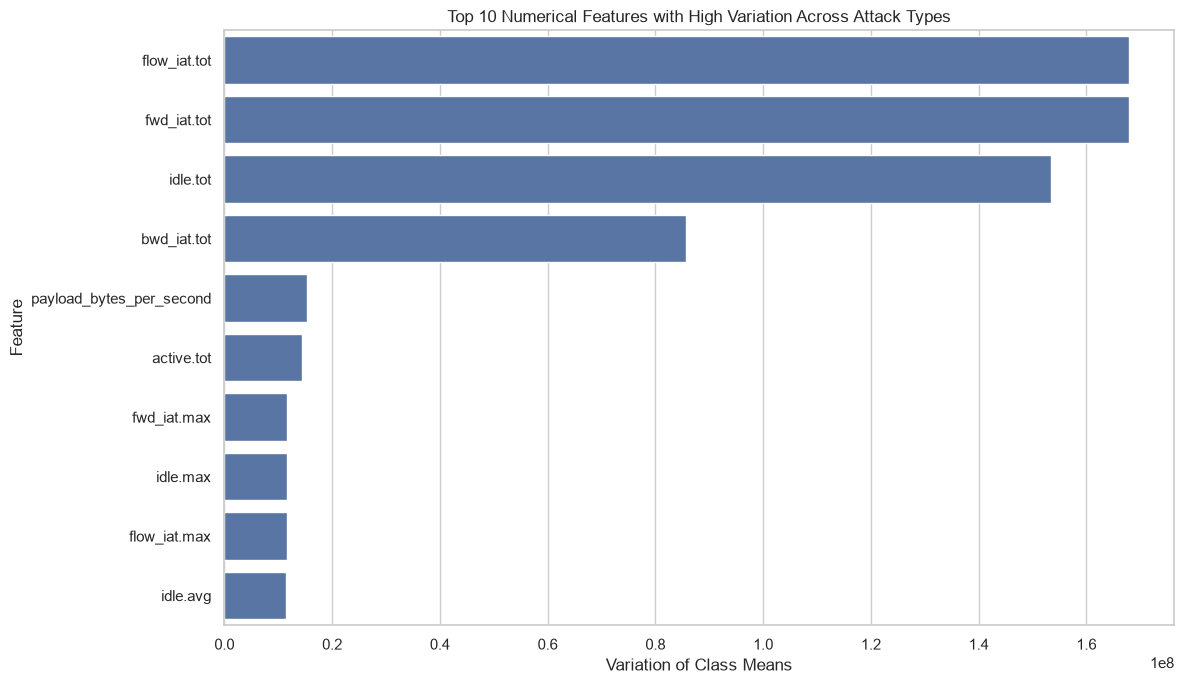

In [26]:
top_features = feature_variation.head(10).index.tolist()

plt.figure(figsize=(12, 7))

sns.barplot(
    x=feature_variation.head(10).values,
    y=feature_variation.head(10).index
)

plt.title("Top 10 Numerical Features with High Variation Across Attack Types")
plt.xlabel("Variation of Class Means")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Observation

The comparison shows that some numerical network-flow features vary substantially across attack types. These features may contain useful discriminative information and can be considered during subsequent feature engineering and model development.

# Section B – Preprocessing & Feature Engineering

The preprocessing stage prepares the RT-IoT2022 dataset for machine learning. The data is checked for missing values, duplicate observations, infinite values and constant features. An index-like column is removed because it does not represent a meaningful network characteristic. Potential outliers are treated using an IQR-based capping strategy rather than deleting observations, since extreme network-flow values may represent genuine attack behaviour.

Categorical features are encoded using One-Hot Encoding, while numerical features are scaled using StandardScaler. The scaler and encoder are fitted only on the training data to prevent data leakage. A stratified train-test split is used to preserve the distribution of the attack classes.

## B1. Data Cleaning

The dataset is checked for missing values, duplicate rows, infinite values and constant features. Columns that do not provide useful predictive information are identified and removed.

In [27]:
# Create a separate copy so that the original dataset remains unchanged
data = df.copy()

print("Original shape:", data.shape)

Original shape: (123117, 85)


In [28]:
# Check missing values
missing = data.isnull().sum()

print("Total missing values:", missing.sum())

if missing.sum() == 0:
    print("No missing values found. No imputation is required.")
else:
    display(
        missing[missing > 0].sort_values(ascending=False).to_frame(
            name="Missing Values"
        )
    )

Total missing values: 0
No missing values found. No imputation is required.


In [29]:
duplicate_count = data.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count == 0:
    print("No duplicate rows found. No duplicate removal is required.")

Number of duplicate rows: 0
No duplicate rows found. No duplicate removal is required.


In [30]:
numeric_columns = data.select_dtypes(include=np.number).columns

infinite_count = np.isinf(data[numeric_columns]).sum().sum()

print("Total infinite values:", infinite_count)

Total infinite values: 0


### Data Cleaning Observation

The dataset contains no missing values, duplicate rows or infinite numerical values, so no imputation or duplicate removal is necessary. This avoids unnecessarily modifying valid network traffic observations.

## Removing Non-Informative Features

The `Unnamed: 0` column appears to be an index-like column rather than a network-flow characteristic, so it is removed. Constant features are also identified because a feature with the same value for every observation cannot help distinguish between attack classes.

In [31]:
# Remove index-like column
if 'Unnamed: 0' in data.columns:
    data = data.drop(columns=['Unnamed: 0'])

print("Shape after removing index column:", data.shape)

Shape after removing index column: (123117, 84)


In [32]:
# Find columns with only one unique value
constant_columns = [
    column for column in data.columns
    if data[column].nunique(dropna=False) <= 1
]

print("Constant columns:")
print(constant_columns)

Constant columns:
['bwd_URG_flag_count']


In [33]:
data = data.drop(columns=constant_columns)

print("Shape after removing constant features:", data.shape)

Shape after removing constant features: (123117, 83)


### Constant Feature Observation

The feature `bwd_URG_flag_count` contains only one unique value across the dataset. Since a constant feature provides no variation and therefore no useful information for distinguishing classes, it is removed before model training.

## Outlier Treatment

Potential outliers were identified during EDA using the IQR method. Because this is a network-security dataset, extreme values may represent genuine attack behaviour and should not automatically be deleted.

Therefore, an IQR-based capping strategy is used. Values below the lower IQR boundary are replaced by the lower boundary, and values above the upper boundary are replaced by the upper boundary. The boundaries are calculated using the training data only to avoid data leakage.

## Train-Test Split

The target variable is `Attack_type`. The data is divided into training and testing sets using a stratified split so that the relative distribution of the attack classes is maintained in both sets.

In [34]:
import sys
!{sys.executable} -m pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = data.drop(columns=['Attack_type'])
y = data['Attack_type']

# Stratified 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set shape: (98493, 82)
Testing set shape: (24624, 82)

Training target distribution:
Attack_type
DOS_SYN_Hping                 0.769
Thing_Speak                   0.066
ARP_poisioning                0.063
MQTT_Publish                  0.034
NMAP_UDP_SCAN                 0.021
NMAP_XMAS_TREE_SCAN           0.016
NMAP_OS_DETECTION             0.016
NMAP_TCP_scan                 0.008
DDOS_Slowloris                0.004
Wipro_bulb                    0.002
Metasploit_Brute_Force_SSH    0.000
NMAP_FIN_SCAN                 0.000
Name: proportion, dtype: float64

Testing target distribution:
Attack_type
DOS_SYN_Hping                 0.769
Thing_Speak                   0.066
ARP_poisioning                0.063
MQTT_Publish                  0.034
NMAP_UDP_SCAN                 0.021
NMAP_XMAS_TREE_SCAN           0.016
NMAP_OS_DETECTION             0.016
NMAP_TCP_scan                 0.008
DDOS_Slowloris                0.004
Wipro_bulb                    0.002
Metasploit_Brute_Force_SSH 

In [36]:
# Identify numerical columns
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

# Identify binary features (0/1) so they are not unnecessarily capped
binary_features = [
    col for col in numeric_features
    if X_train[col].nunique() <= 2
]

# Continuous numerical features
continuous_features = [
    col for col in numeric_features
    if col not in binary_features
]

print("Numerical features:", len(numeric_features))
print("Binary features:", len(binary_features))
print("Continuous features:", len(continuous_features))

Numerical features: 80
Binary features: 1
Continuous features: 79


In [37]:
# Calculate IQR limits using training data only

lower_limits = {}
upper_limits = {}

for column in continuous_features:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limits[column] = Q1 - 1.5 * IQR
    upper_limits[column] = Q3 + 1.5 * IQR

print("IQR limits calculated using training data.")

IQR limits calculated using training data.


In [38]:
# Apply the same training-derived limits to train and test data

for column in continuous_features:
    X_train[column] = X_train[column].clip(
        lower=lower_limits[column],
        upper=upper_limits[column]
    )
    
    X_test[column] = X_test[column].clip(
        lower=lower_limits[column],
        upper=upper_limits[column]
    )

print("IQR-based outlier capping completed.")

IQR-based outlier capping completed.


## B3. Feature Engineering

A new feature called `total_pkts` is created by adding forward and backward packet counts. This represents the total number of packets exchanged during a network flow and may provide a simpler overall measure of traffic volume for the classification models.

In [39]:
# Feature engineering: total packets in both directions

X_train['total_pkts'] = (
    X_train['fwd_pkts_tot'] +
    X_train['bwd_pkts_tot']
)

X_test['total_pkts'] = (
    X_test['fwd_pkts_tot'] +
    X_test['bwd_pkts_tot']
)

print("New feature 'total_pkts' created.")
display(X_train[['fwd_pkts_tot', 'bwd_pkts_tot', 'total_pkts']].head())

New feature 'total_pkts' created.


,fwd_pkts_tot,bwd_pkts_tot,total_pkts
72497,1,1,2
64780,1,1,2
90194,1,1,2
55247,1,1,2
116971,1,1,2


### Additional Engineered Feature

A forward-to-backward packet ratio is created to represent the directionality of the network flow. The ratio can help distinguish traffic patterns where packets are predominantly sent in one direction.

In [40]:
# Forward-to-backward packet ratio
# +1 prevents division by zero

X_train['fwd_bwd_pkt_ratio'] = (
    X_train['fwd_pkts_tot'] /
    (X_train['bwd_pkts_tot'] + 1)
)

X_test['fwd_bwd_pkt_ratio'] = (
    X_test['fwd_pkts_tot'] /
    (X_test['bwd_pkts_tot'] + 1)
)

print("New feature 'fwd_bwd_pkt_ratio' created.")
display(
    X_train[
        ['fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_bwd_pkt_ratio']
    ].head()
)

New feature 'fwd_bwd_pkt_ratio' created.


,fwd_pkts_tot,bwd_pkts_tot,fwd_bwd_pkt_ratio
72497,1,1,0.5
64780,1,1,0.5
90194,1,1,0.5
55247,1,1,0.5
116971,1,1,0.5


## B2. Encoding and Scaling

The categorical features `proto` and `service` are converted into numerical representations using One-Hot Encoding. Numerical features are standardized using StandardScaler so that features with different numerical ranges can be used effectively by machine learning algorithms.

The encoder and scaler are fitted only on the training data and then used to transform both the training and testing data. This prevents information from the test set from leaking into the training process.

In [41]:
categorical_features = X_train.select_dtypes(
    include=['object', 'string']
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numeric_features))

Categorical features:
['proto', 'service']

Number of numerical features: 82


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [43]:
# Fit the preprocessing pipeline ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the already-fitted pipeline
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (98493, 95)
Processed testing shape: (24624, 95)


In [44]:
# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

print("Final processed training data:")
display(X_train_processed.head())

print("Final processed shape:", X_train_processed.shape)

Final processed training data:


,num__id.orig_p,num__id.resp_p,num__flow_duration,num__fwd_pkts_tot,num__bwd_pkts_tot,num__fwd_data_pkts_tot,num__bwd_data_pkts_tot,num__fwd_pkts_per_sec,num__bwd_pkts_per_sec,num__flow_pkts_per_sec,num__down_up_ratio,num__fwd_header_size_tot,num__fwd_header_size_min,num__fwd_header_size_max,num__bwd_header_size_tot,num__bwd_header_size_min,num__bwd_header_size_max,num__flow_FIN_flag_count,num__flow_SYN_flag_count,num__flow_RST_flag_count,num__fwd_PSH_flag_count,num__bwd_PSH_flag_count,num__flow_ACK_flag_count,num__fwd_URG_flag_count,num__flow_CWR_flag_count,num__flow_ECE_flag_count,num__fwd_pkts_payload.min,num__fwd_pkts_payload.max,num__fwd_pkts_payload.tot,num__fwd_pkts_payload.avg,num__fwd_pkts_payload.std,num__bwd_pkts_payload.min,num__bwd_pkts_payload.max,num__bwd_pkts_payload.tot,num__bwd_pkts_payload.avg,num__bwd_pkts_payload.std,num__flow_pkts_payload.min,num__flow_pkts_payload.max,num__flow_pkts_payload.tot,num__flow_pkts_payload.avg,num__flow_pkts_payload.std,num__fwd_iat.min,num__fwd_iat.max,num__fwd_iat.tot,num__fwd_iat.avg,num__fwd_iat.std,num__bwd_iat.min,num__bwd_iat.max,num__bwd_iat.tot,num__bwd_iat.avg,num__bwd_iat.std,num__flow_iat.min,num__flow_iat.max,num__flow_iat.tot,num__flow_iat.avg,num__flow_iat.std,num__payload_bytes_per_second,num__fwd_subflow_pkts,num__bwd_subflow_pkts,num__fwd_subflow_bytes,num__bwd_subflow_bytes,num__fwd_bulk_bytes,num__bwd_bulk_bytes,num__fwd_bulk_packets,num__bwd_bulk_packets,num__fwd_bulk_rate,num__bwd_bulk_rate,num__active.min,num__active.max,num__active.tot,num__active.avg,num__active.std,num__idle.min,num__idle.max,num__idle.tot,num__idle.avg,num__idle.std,num__fwd_init_window_size,num__bwd_init_window_size,num__fwd_last_window_size,num__total_pkts,num__fwd_bwd_pkt_ratio,cat__proto_icmp,cat__proto_tcp,cat__proto_udp,cat__service_-,cat__service_dhcp,cat__service_dns,cat__service_http,cat__service_irc,cat__service_mqtt,cat__service_ntp,cat__service_radius,cat__service_ssh,cat__service_ssl
72497,1.045232,0.0,0.292607,0.0,0.0,0.0,0.0,-0.411244,-0.411092,-0.411170,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.128748,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.458836,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.361585,0.288476,0.288476,0.288476,0.0,-0.381881,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.294758,0.288835,0.288835,0.288835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
64780,0.642655,0.0,0.292607,0.0,0.0,0.0,0.0,-0.411244,-0.411092,-0.411170,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.128748,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.458836,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.361585,0.288476,0.288476,0.288476,0.0,-0.381881,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.294758,0.288835,0.288835,0.288835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
90194,1.355589,0.0,0.007906,0.0,0.0,0.0,0.0,-0.242942,-0.242806,-0.242875,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.128748,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.458836,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.005388,-0.048263,-0.048263,-0.048263,0.0,-0.214958,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.043366,-0.047952,-0.047952,-0.047952,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
55247,0.142242,0.0,-0.846199,0.0,0.0,0.0,0.0,1.877663,1.877598,1.877636,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.128748,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.458836,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.849485,-0.856437,-0.856437,-0.856437,0.0,1.888265,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.854864,-0.856238,-0.856238,-0.856238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
116971,0.859532,0.0,0.577309,0.0,0.0,0.0,0.0,-0.497415,-0.497255,-0.497336,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.

Final processed shape: (98493, 95)


In [45]:
# Check means of scaled numerical features

scaled_means = X_train_processed[
    [col for col in X_train_processed.columns if col.startswith('num__')]
].mean()

print("Mean of scaled numerical features:")
display(scaled_means.head(10))

Mean of scaled numerical features:


num__id.orig_p            1.875678e-16
num__id.resp_p            0.000000e+00
num__flow_duration        2.005532e-17
num__fwd_pkts_tot         0.000000e+00
num__bwd_pkts_tot         0.000000e+00
num__fwd_data_pkts_tot    0.000000e+00
num__bwd_data_pkts_tot    0.000000e+00
num__fwd_pkts_per_sec    -9.176392e-17
num__bwd_pkts_per_sec    -9.147535e-17
num__flow_pkts_per_sec    8.642545e-17
dtype: float64

## Section B Summary

The RT-IoT2022 dataset was successfully prepared for machine learning. The dataset contained no missing values, duplicate rows or infinite values, so no imputation or duplicate removal was required. The index-like `Unnamed: 0` column and the constant feature `bwd_URG_flag_count` were removed because they do not provide useful predictive information.

Potential outliers were identified during EDA and treated using IQR-based capping rather than deleting observations, since extreme network-flow values may represent genuine attack behaviour. The IQR limits were calculated using only the training data.

Two engineered features, `total_pkts` and `fwd_bwd_pkt_ratio`, were created to represent overall traffic volume and traffic directionality. The categorical features `proto` and `service` were one-hot encoded, while numerical features were standardized using StandardScaler. The preprocessing transformations were fitted only on the training data to prevent data leakage.

A stratified 80:20 train-test split was used to maintain the distribution of the different attack classes.

# Part D: Classification Model Implementation and Evaluation

In this section, five classification algorithms are implemented and trained using the training dataset. Predictions are generated for the test dataset.

The algorithms used are:

1. Logistic Regression
2. Decision Tree Classifier
3. Support Vector Classifier (SVC)
4. K-Nearest Neighbors (KNN)
5. Gaussian Naive Bayes

The models are evaluated using:

- Weighted F1-score
- Confusion Matrix

A preliminary comparison table is also presented.

## 1. Import Required Libraries

The required classification algorithms and evaluation metrics are imported
from scikit-learn.

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt

## Data Preparation for Classification

Categorical features are converted into numerical values so that the
classification algorithms can process the dataset.

In [47]:
# Use the already preprocessed data from Section B
# This ensures all five Part-A algorithms use the same train/test split
# and the same fitted encoding and scaling.

X_train = X_train_processed
X_test = X_test_processed

print("Using the preprocessed training and testing data.")
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Using the preprocessed training and testing data.
Training set shape: (98493, 95)
Testing set shape: (24624, 95)
Training labels: (98493,)
Testing labels: (24624,)


### Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.
Stratification is used to maintain the class distribution in both sets.

In [48]:
# The train-test split was already performed in Section B using stratification.
# No second split is performed here.

print("Train/test split reused from preprocessing section.")
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Train/test split reused from preprocessing section.
Training set: (98493, 95)
Testing set: (24624, 95)


## 2. Logistic Regression

Logistic Regression is a supervised classification algorithm used to predict
the class label of each observation.

The model is trained using the training data and predictions are generated
for the test data.

In [49]:
# Create Logistic Regression model
# Scaling was already performed in the preprocessing pipeline.
# A larger max_iter is used because the previous 1000-iteration limit
# produced a convergence warning.

lr_model = LogisticRegression(max_iter=2000, random_state=42)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression predictions generated successfully.")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Weighted F1-Score:", f1_score(y_test, lr_pred, average='weighted'))

Logistic Regression predictions generated successfully.
Accuracy: 0.9761208576998051
Weighted F1-Score: 0.9750911113083373


## 3. Decision Tree Classifier

Decision Tree is a supervised classification algorithm that makes decisions
by splitting the data based on feature values.

The trained model is used to generate predictions on the test dataset.

In [50]:
# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree predictions generated successfully.")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Weighted F1-Score:", f1_score(y_test, dt_pred, average='weighted'))

Decision Tree predictions generated successfully.
Accuracy: 0.9957358674463938
Weighted F1-Score: 0.9957164216579659


## 4. Support Vector Machine (SVC)

Support Vector Classification is a supervised classification algorithm that
finds a decision boundary that separates classes. The features are already
scaled because SVC is sensitive to feature scale.

In [51]:
# Create SVC model
svc_model = SVC()

svc_model.fit(X_train, y_train)

svc_pred = svc_model.predict(X_test)

print("Support Vector Machine predictions generated successfully.")
print("Accuracy:", accuracy_score(y_test, svc_pred))
print("Weighted F1-Score:", f1_score(y_test, svc_pred, average='weighted'))

Support Vector Machine predictions generated successfully.
Accuracy: 0.978638726445744
Weighted F1-Score: 0.9782297802669636


## 5. K-Nearest Neighbors (KNN)

K-Nearest Neighbors classifies an observation based on the classes of its
nearest training observations. Feature scaling is important because KNN
uses distance between observations.

In [52]:
# Create KNN model
knn_model = KNeighborsClassifier()

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("KNN predictions generated successfully.")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("Weighted F1-Score:", f1_score(y_test, knn_pred, average='weighted'))

KNN predictions generated successfully.
Accuracy: 0.9930149447693307
Weighted F1-Score: 0.9929166243920985


## 6. Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classification algorithm based on
Bayes' theorem. It assumes conditional independence between features
given the class.

In [53]:
# Create Gaussian Naive Bayes model
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes predictions generated successfully.")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print("Weighted F1-Score:", f1_score(y_test, nb_pred, average='weighted'))

Naive Bayes predictions generated successfully.
Accuracy: 0.7902452891487979
Weighted F1-Score: 0.8321723751634352


## 7. Accuracy and Weighted F1-Score Evaluation

Review 1 requires Accuracy and weighted F1-score for each of the five
Part-A classification algorithms.

In [59]:
# Calculate evaluation metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)
svc_accuracy = accuracy_score(y_test, svc_pred)
knn_accuracy = accuracy_score(y_test, knn_pred)
nb_accuracy = accuracy_score(y_test, nb_pred)

lr_f1 = f1_score(y_test, lr_pred, average='weighted')
dt_f1 = f1_score(y_test, dt_pred, average='weighted')
svc_f1 = f1_score(y_test, svc_pred, average='weighted')
knn_f1 = f1_score(y_test, knn_pred, average='weighted')
nb_f1 = f1_score(y_test, nb_pred, average='weighted')


## 8. Preliminary Comparison of Classification Algorithms

The five Review 1 Part-A algorithms are compared using Accuracy and
weighted F1-score. The same preprocessed train/test split is used for all
models so the comparison is fair.

In [60]:
comparison_table = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "Decision Tree",
        "Support Vector Machine",
        "KNN",
        "Naive Bayes"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        svc_accuracy,
        knn_accuracy,
        nb_accuracy
    ],
    "Weighted F1-Score": [
        lr_f1,
        dt_f1,
        svc_f1,
        knn_f1,
        nb_f1
    ]
})

comparison_table

,Algorithm,Accuracy,Weighted F1-Score
0,Logistic Regression,0.976121,0.975091
1,Decision Tree,0.995736,0.995716
2,Support Vector Machine,0.978639,0.978230
3,KNN,0.993015,0.992917
4,Naive Bayes,0.790245,0.832172


## 9. Confusion Matrix

Confusion matrices are generated for all five classification algorithms.

A confusion matrix shows the actual class labels against the predicted
class labels and helps identify correctly and incorrectly classified samples.

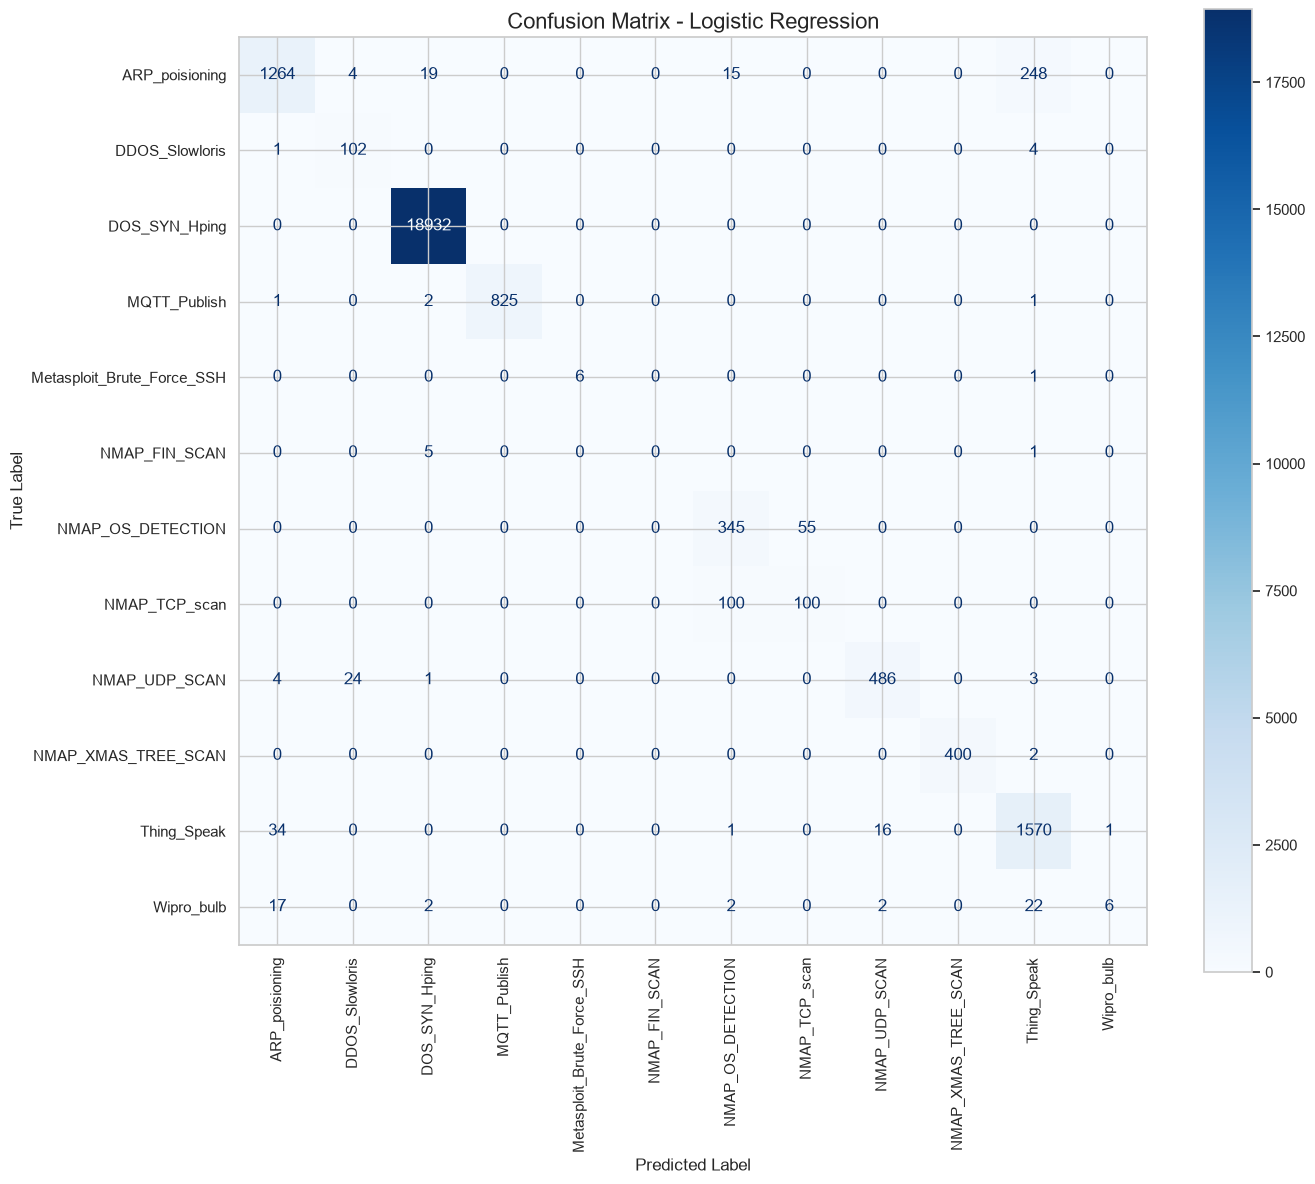

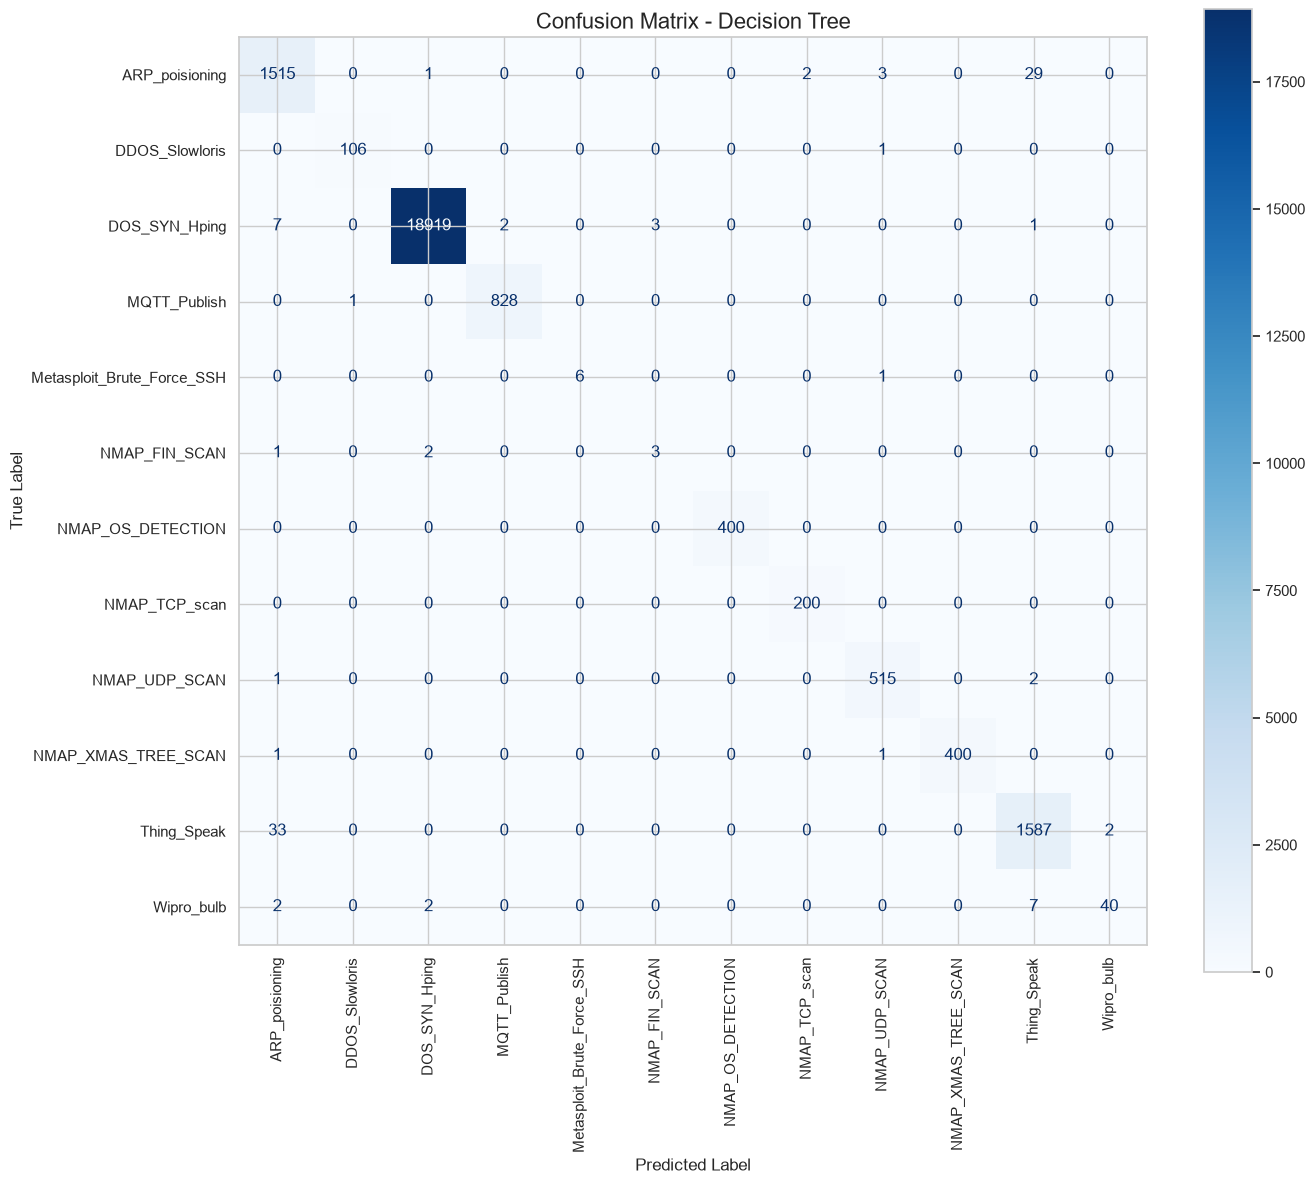

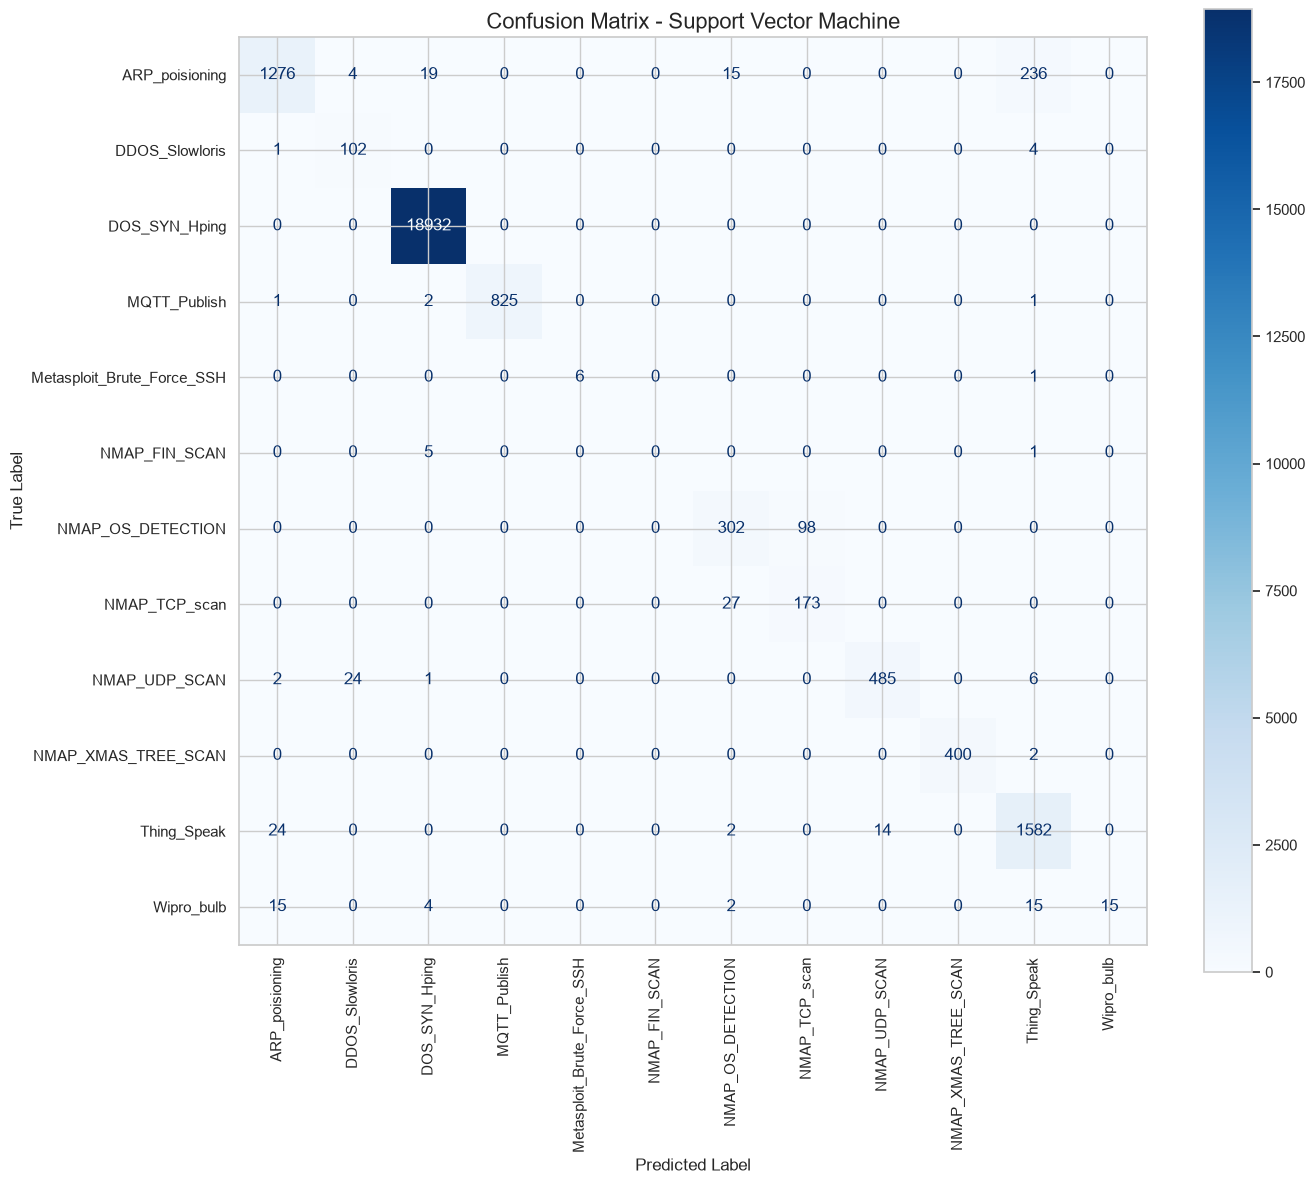

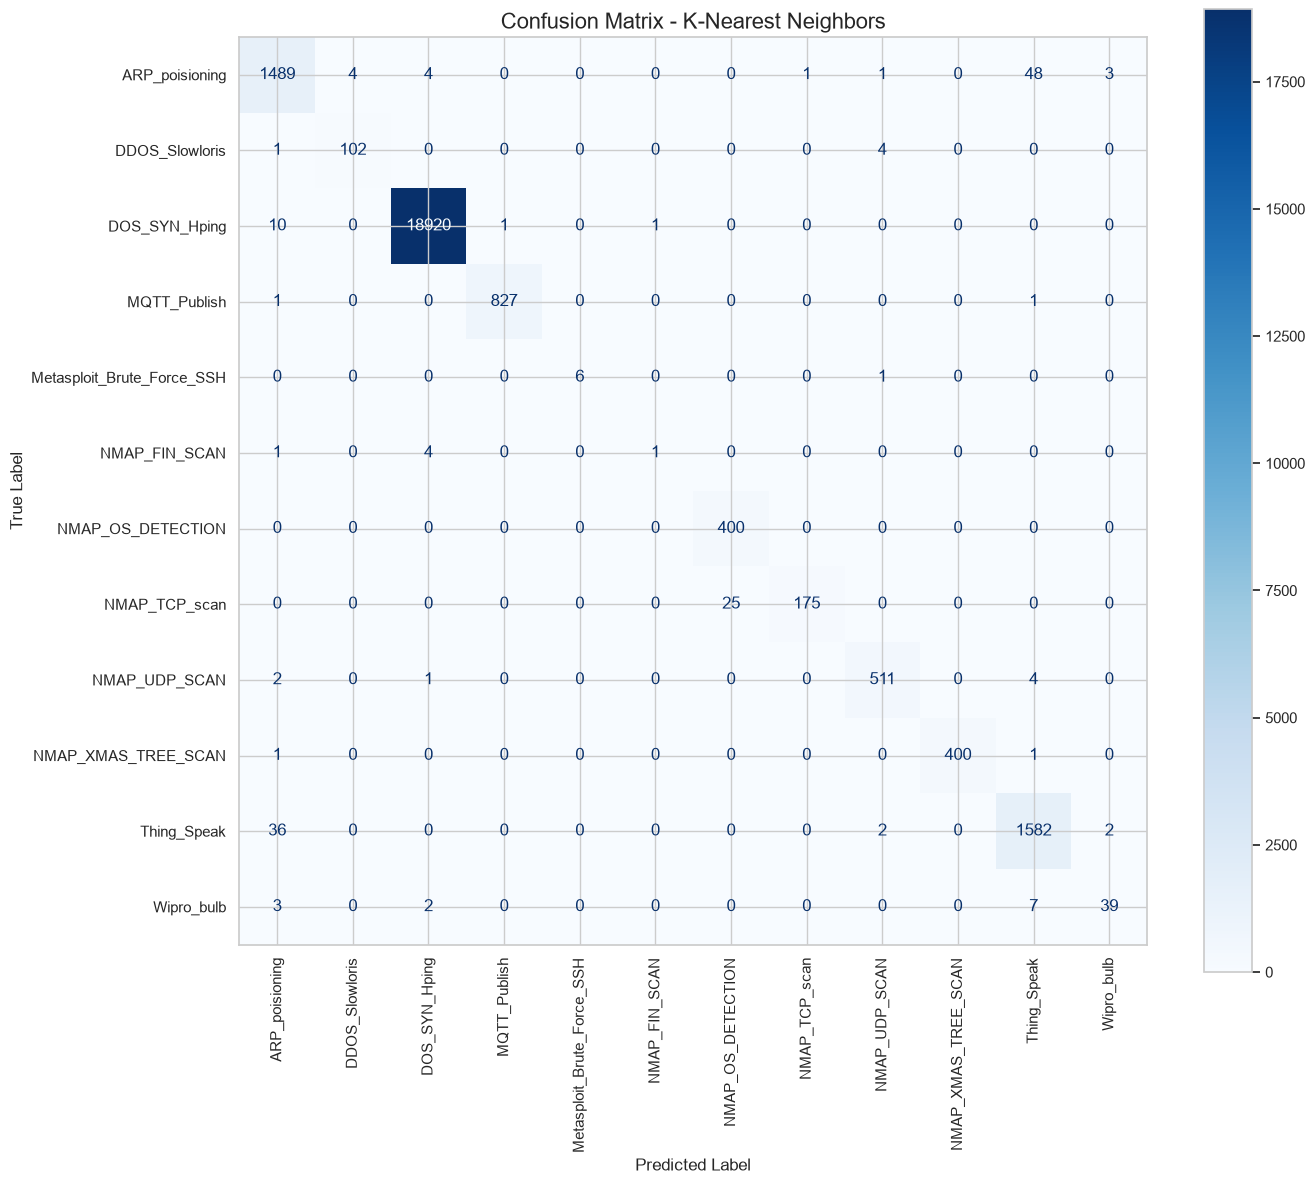

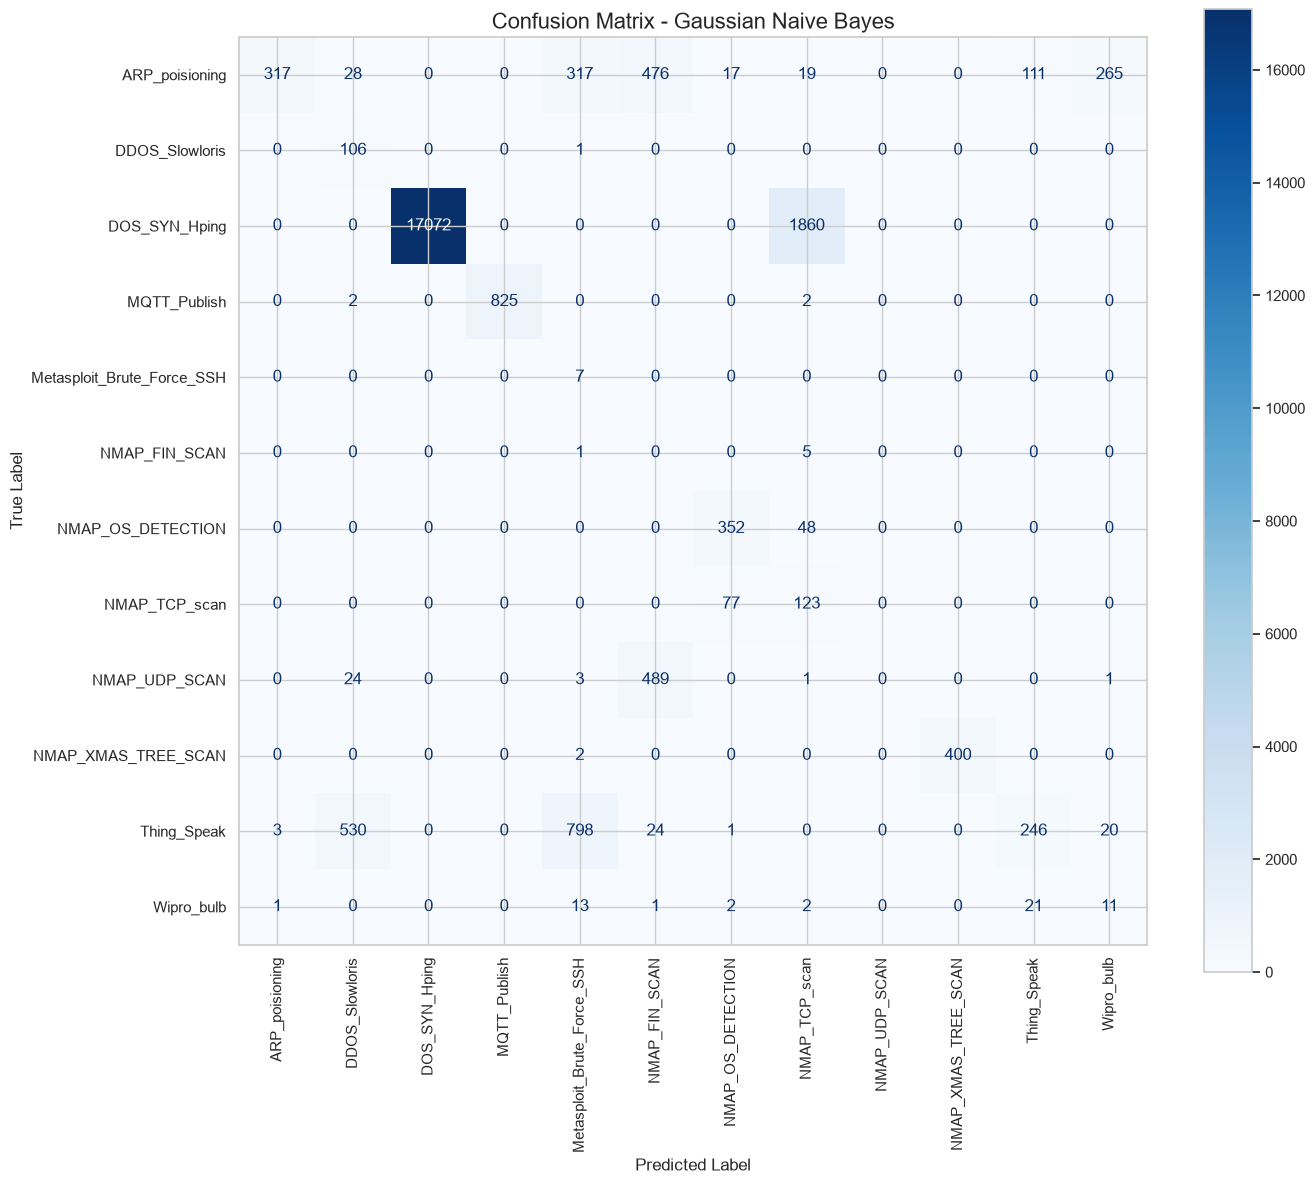

In [58]:
# ============================================================
# Confusion Matrices for All 5 Review 1 Classification Models
# ============================================================

models_predictions = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Support Vector Machine": svc_pred,
    "K-Nearest Neighbors": knn_pred,
    "Gaussian Naive Bayes": nb_pred
}

for model_name, predictions in models_predictions.items():

    fig, ax = plt.subplots(figsize=(14, 12))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        ax=ax,
        xticks_rotation=90,
        cmap="Blues",
        values_format="d"
    )

    ax.set_title(
        f"Confusion Matrix - {model_name}",
        fontsize=16
    )

    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)

    plt.tight_layout()
    plt.show()

## 10. Part A Summary

Five Review 1 Part-A classification algorithms were implemented:

1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine (SVC)

All models use the same stratified train/test split and the same
training-fitted preprocessing pipeline. Accuracy, weighted F1-score, and
confusion matrices are reported as required for Review 1.